# Import Library

In [ ]:
!pip install filelock>=3.15 pytensor monai[all]

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"


In [ ]:
import os, time, math, json, random
import time
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import monai
print(monai.__version__)


import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math

from tqdm import tqdm
from torch.cuda import amp
from scipy.ndimage import distance_transform_edt, binary_erosion
from skimage.filters import threshold_otsu
from sklearn.model_selection import train_test_split
from monai.utils import set_determinism
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd, EnsureTyped
from monai.data import CacheDataset
from torch.utils.data import Dataset, DataLoader
from torch.cuda import amp
from torch import optim, amp
from datetime import datetime
from matplotlib.colors import ListedColormap
from glob import glob
from scipy.ndimage import distance_transform_edt, binary_erosion
from monai.metrics import DiceMetric, MeanIoU
from monai.utils.enums import MetricReduction
from copy import deepcopy
from collections import deque


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


1.5.2
Using device: cuda


In [ ]:
!pip list > dependencies.txt

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = '/content/drive/MyDrive/CKD-Trans'

# Data Eksplorasi

### Data

In [ ]:
# # Path dataset

# BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"
# TRAIN_DIR = os.path.join(BASE_DIR, "Training")
# VAL_DIR   = os.path.join(BASE_DIR, "Validation")

# print("Train folder path :", TRAIN_DIR)
# print("Validation folder path :", VAL_DIR)

# # Modalitas
# modalities = ["t1c", "t1n", "t2f", "t2w"]

# # List kasus (pakai glob)

# train_cases = sorted([os.path.basename(p) for p in glob.glob(os.path.join(TRAIN_DIR, "BraTS-*"))])
# val_cases   = sorted([os.path.basename(p) for p in glob.glob(os.path.join(VAL_DIR, "BraTS-*"))])

# print(f"\nTotal Training Cases   : {len(train_cases)}")
# print(f"Total Validation Cases : {len(val_cases)}")

# # Helpers

# def expected_paths(case_dir, case_name):
#     mod_paths = {m: os.path.join(case_dir, f"{case_name}-{m}.nii.gz") for m in modalities}
#     seg_path  = os.path.join(case_dir, f"{case_name}-seg.nii.gz")
#     return mod_paths, seg_path

# def load_unique_labels(seg_path):
#     seg = nib.load(seg_path).get_fdata()
#     uniq = np.unique(seg).astype(int).tolist()
#     return uniq

# # Cek struktur TRAINING

# missing_train = []
# bad_label_train = []

# print("\n Mengecek struktur TRAINING (semua kasus)...")
# for case_name in tqdm(train_cases):
#     case_dir = os.path.join(TRAIN_DIR, case_name)
#     mod_paths, seg_path = expected_paths(case_dir, case_name)

#     # cek modalitas
#     missing_mods = [m for m,p in mod_paths.items() if not os.path.exists(p)]
#     # cek seg
#     has_seg = os.path.exists(seg_path)

#     if missing_mods or (not has_seg):
#         missing_train.append((case_name, missing_mods, has_seg))
#         continue

#     # cek label values 0..4
#     try:
#         uniq = load_unique_labels(seg_path)
#         bad = [u for u in uniq if u not in [0,1,2,3,4]]
#         if bad:
#             bad_label_train.append((case_name, uniq))
#     except Exception as e:
#         bad_label_train.append((case_name, f"ERROR reading seg: {e}"))

# print(f" TRAIN OK: {len(train_cases) - len(missing_train)} / {len(train_cases)}")
# if missing_train:
#     print("Contoh kasus TRAIN bermasalah (maks 10):")
#     for x in missing_train[:10]:
#         print(" -", x)

# if bad_label_train:
#     print("\n TRAIN label bermasalah (unique bukan 0..4) (maks 10):")
#     for x in bad_label_train[:10]:
#         print(" -", x)

# # Cek struktur VALIDATION
# # - seg boleh ada atau tidak
# missing_val = []
# val_with_seg = 0
# val_without_seg = 0
# bad_label_val = []

# print("\n Mengecek struktur VALIDATION (semua kasus)...")
# for case_name in tqdm(val_cases):
#     case_dir = os.path.join(VAL_DIR, case_name)
#     mod_paths, seg_path = expected_paths(case_dir, case_name)

#     missing_mods = [m for m,p in mod_paths.items() if not os.path.exists(p)]
#     has_seg = os.path.exists(seg_path)

#     if missing_mods:
#         missing_val.append((case_name, missing_mods))
#         continue

#     if has_seg:
#         val_with_seg += 1
#         # kalau ada seg, cek label values
#         try:
#             uniq = load_unique_labels(seg_path)
#             bad = [u for u in uniq if u not in [0,1,2,3,4]]
#             if bad:
#                 bad_label_val.append((case_name, uniq))
#         except Exception as e:
#             bad_label_val.append((case_name, f"ERROR reading seg: {e}"))
#     else:
#         val_without_seg += 1

# print(f" VAL OK (modalitas lengkap): {len(val_cases) - len(missing_val)} / {len(val_cases)}")
# print(f"   • VAL dengan seg   : {val_with_seg}")
# print(f"   • VAL tanpa seg    : {val_without_seg}")

# if missing_val:
#     print("Contoh kasus VAL bermasalah (maks 10):")
#     for x in missing_val[:10]:
#         print(" -", x)

# if bad_label_val:
#     print("\nVAL label bermasalah (unique bukan 0..4) (maks 10):")
#     for x in bad_label_val[:10]:
#         print(" -", x)

# # Simpan log

# with open("dataset_structure_log.txt", "w") as f:
#     f.write(f"TRAIN missing cases ({len(missing_train)}): {missing_train}\n")
#     f.write(f"TRAIN bad label cases ({len(bad_label_train)}): {bad_label_train}\n")
#     f.write(f"VAL missing cases ({len(missing_val)}): {missing_val}\n")
#     f.write(f"VAL bad label cases ({len(bad_label_val)}): {bad_label_val}\n")
#     f.write(f"VAL with seg: {val_with_seg}, VAL without seg: {val_without_seg}\n")

# print("\nLog struktur dataset disimpan di 'dataset_structure_log.txt'")

# # Contoh baca 1 sample training + info label

# if len(train_cases) > 0:
#     print("\n Contoh sample TRAINING:")
#     sample_train = train_cases[0]
#     train_case_dir = os.path.join(TRAIN_DIR, sample_train)
#     mod_paths, seg_path = expected_paths(train_case_dir, sample_train)

#     imgs = [nib.load(mod_paths[m]).get_fdata() for m in modalities]
#     stack = np.stack(imgs, axis=-1)
#     print("Image shape :", stack.shape)

#     if os.path.exists(seg_path):
#         seg = nib.load(seg_path).get_fdata()
#         print("Label shape :", seg.shape)
#         print("Unique label values:", np.unique(seg).astype(int).tolist())

# # Contoh baca 1 sample validation + seg optional

# if len(val_cases) > 0:
#     print("\n Contoh sample VALIDATION:")
#     sample_val = val_cases[0]
#     val_case_dir = os.path.join(VAL_DIR, sample_val)
#     mod_paths, seg_path = expected_paths(val_case_dir, sample_val)

#     imgs = [nib.load(mod_paths[m]).get_fdata() for m in modalities]
#     stack = np.stack(imgs, axis=-1)
#     print("Image shape :", stack.shape)
#     print("Intensity range :", float(np.min(stack)), "→", float(np.max(stack)))

#     if os.path.exists(seg_path):
#         seg = nib.load(seg_path).get_fdata()
#         print("VAL has seg. Unique label values:", np.unique(seg).astype(int).tolist())
#     else:
#         print("VAL has no seg (unlabeled / infer-only).")


### Visualisasi Data

In [ ]:


# # =====================================
# # Path dataset
# # =====================================
# BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"
# TRAIN_DIR = os.path.join(BASE_DIR, "Training")
# VAL_DIR   = os.path.join(BASE_DIR, "Validation")

# # =====================================
# # Pilih kasus (PASTIKAN case ini ada di folder Training)
# # contoh format biasanya: BraTS-GLI-xxxxx-xxx (cek nama foldermu)
# # =====================================
# sample_case = "BraTS-GLI-00005-100"  # <-- GANTI sesuai folder yang ada
# CASE_DIR = os.path.join(TRAIN_DIR, sample_case)

# if not os.path.isdir(CASE_DIR):
#     raise FileNotFoundError(f"Case folder tidak ditemukan: {CASE_DIR}")

# # =====================================
# # Modalitas (sesuaikan dengan dataset kamu)
# # Kamu pakai: t1c, t1n, t2f, t2w
# # =====================================
# modalities = ["t2f", "t1n", "t1c", "t2w"]  # urutan agar visual rapi
# mod_labels = ["T2-FLAIR (t2f)", "T1-Native (t1n)", "T1-CE (t1c)", "T2-Weighted (t2w)"]

# def normalize_01(x: np.ndarray) -> np.ndarray:
#     x = x.astype(np.float32)
#     lo, hi = np.percentile(x, (1, 99))
#     x = np.clip(x, lo, hi)
#     x = (x - lo) / (hi - lo + 1e-8)
#     return x

# # =====================================
# # Load image per modalitas
# # =====================================
# images = []
# loaded_modalities = []
# for mod in modalities:
#     fpath = os.path.join(CASE_DIR, f"{sample_case}-{mod}.nii.gz")
#     if not os.path.exists(fpath):
#         print(f" File tidak ditemukan: {fpath}")
#         continue
#     img = nib.load(fpath).get_fdata()
#     images.append(img)
#     loaded_modalities.append(mod)

# if len(images) == 0:
#     raise RuntimeError("Tidak ada modalitas yang berhasil diload. Cek nama file & folder.")

# img_data = np.stack(images, axis=-1)  # (H, W, D, C)
# H, W, D, C = img_data.shape
# print("Loaded image stack:", img_data.shape, "| modalities:", loaded_modalities)

# # =====================================
# # Load label (jika ada)
# # =====================================
# label_path = os.path.join(CASE_DIR, f"{sample_case}-seg.nii.gz")
# label_data = None
# if os.path.exists(label_path):
#     label_data = nib.load(label_path).get_fdata()
#     uniq = np.unique(label_data).astype(int).tolist()
#     print("Label found. Unique labels:", uniq)
# else:
#     print("No label file found (infer-only case).")

# # =====================================
# # Pilih slice yang lebih informatif:
# # - kalau label ada: slice dengan jumlah tumor (label>0) terbesar
# # - kalau tidak ada: slice tengah
# # =====================================
# if label_data is not None:
#     tumor_counts = [(z, int((label_data[:, :, z] > 0).sum())) for z in range(D)]
#     best_z, best_cnt = max(tumor_counts, key=lambda x: x[1])
#     z_slice = best_z
#     print(f"Using tumor-max slice z={z_slice} (tumor voxels={best_cnt})")
# else:
#     z_slice = D // 2
#     print(f"Using mid slice z={z_slice}")

# # =====================================
# # Plot
# # =====================================
# # normalisasi untuk visual per modalitas
# img_vis = np.zeros_like(img_data, dtype=np.float32)
# for i in range(C):
#     img_vis[..., i] = normalize_01(img_data[..., i])

# plt.figure(figsize=(14, 6))

# # tampilkan modalitas
# for i in range(C):
#     plt.subplot(2, 3, i + 1)
#     plt.imshow(img_vis[:, :, z_slice, i].T, cmap="gray", origin="lower")
#     # judul: gunakan label yang sesuai index-nya
#     title = mod_labels[modalities.index(loaded_modalities[i])] if loaded_modalities[i] in modalities else loaded_modalities[i]
#     plt.title(title)
#     plt.axis("off")

# # label + overlay jika ada
# if label_data is not None:
#     plt.subplot(2, 3, 5)
#     plt.imshow(label_data[:, :, z_slice].T, cmap="tab10", origin="lower", vmin=0, vmax=4)
#     plt.title("Segmentation Label (0..4)")
#     plt.axis("off")

#     plt.subplot(2, 3, 6)
#     plt.imshow(img_vis[:, :, z_slice, 0].T, cmap="gray", origin="lower")  # pakai modalitas pertama (t2f)
#     plt.imshow(label_data[:, :, z_slice].T, cmap="tab10", alpha=0.35, origin="lower", vmin=0, vmax=4)
#     plt.title("Overlay (base=T2-FLAIR) + Label")
#     plt.axis("off")
# else:
#     plt.subplot(2, 3, 5)
#     plt.text(0.1, 0.5, "No label available\n(infer-only case)", fontsize=12)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


In [ ]:
# # =====================================
# # Path dataset (ubah sesuai drive kamu)
# # =====================================
# BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"
# TRAIN_DIR = os.path.join(BASE_DIR, "Training")
# VAL_DIR   = os.path.join(BASE_DIR, "Validation")

# # Pilih contoh kasus

# train_cases = sorted([c for c in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, c)) and c.startswith("BraTS-")])
# if len(train_cases) == 0:
#     raise RuntimeError(f"Tidak ada folder kasus BraTS-* di: {TRAIN_DIR}")

# sample_case = train_cases[0]  # bisa ganti index, misal train_cases[10]
# CASE_DIR = os.path.join(TRAIN_DIR, sample_case)
# print(" sample_case:", sample_case)

# # Modalitas

# modalities = ["t2f", "t1n", "t1c", "t2w"]
# mod_labels = ["T2-FLAIR (t2f)", "T1-Native (t1n)", "T1-CE (t1c)", "T2-Weighted (t2w)"]

# # Helper normalisasi untuk visual

# def normalize_01(x: np.ndarray) -> np.ndarray:
#     x = x.astype(np.float32)
#     lo, hi = np.percentile(x, (1, 99))
#     x = np.clip(x, lo, hi)
#     return (x - lo) / (hi - lo + 1e-8)

# # Load Data

# images = []
# loaded_mods = []
# for mod in modalities:
#     path = os.path.join(CASE_DIR, f"{sample_case}-{mod}.nii.gz")
#     if not os.path.exists(path):
#         print(f" File tidak ditemukan: {path}")
#         continue
#     img = nib.load(path).get_fdata()
#     images.append(img)
#     loaded_mods.append(mod)

# if len(images) == 0:
#     raise FileNotFoundError("Tidak ada file modalitas yang ditemukan. Cek nama file & folder dataset.")

# img_data = np.stack(images, axis=-1)  # (H, W, D, C)
# H, W, D, C = img_data.shape
# print("Image shape:", img_data.shape, "| loaded:", loaded_mods)

# # Label (kalau ada)
# label_path = os.path.join(CASE_DIR, f"{sample_case}-seg.nii.gz")
# label_data = nib.load(label_path).get_fdata() if os.path.exists(label_path) else None

# if label_data is not None:
#     uniq = np.unique(label_data).astype(int).tolist()
#     print("Label shape:", label_data.shape)
#     print("Unique labels:", uniq)
# else:
#     print(" Label tidak ada (infer-only case).")


# if label_data is not None:
#     tumor_per_slice = np.array([(label_data[:, :, z] > 0).sum() for z in range(D)], dtype=np.int64)
#     if tumor_per_slice.max() == 0:
#         print(" Tidak ditemukan tumor (label>0), pakai slice tengah.")
#         z0 = D // 2
#     else:
#         z0 = int(np.argmax(tumor_per_slice))
#     slices = [max(0, z0 - 1), z0, min(D - 1, z0 + 1)]
# else:
#     z0 = D // 2
#     slices = [max(0, z0 - 1), z0, min(D - 1, z0 + 1)]

# print(f" Slice yang divisualisasikan: {slices}")

# # =====================================
# # Colormap label untuk 0..4
# # 0=BG, 1=ET, 2=NETC, 3=SNFH, 4=RC (sesuai pipeline kamu)
# # =====================================
# label_names = ["BG", "ET", "NETC", "SNFH", "RC"]
# colors = ["black", "red", "orange", "lime", "cyan"]  # 5 warna (0..4)
# custom_cmap = ListedColormap(colors)

# # Visualisasi Multi-Slice

# n_rows = len(slices)
# n_cols = C + (1 if label_data is not None else 0)
# plt.figure(figsize=(4 * n_cols, 4 * n_rows))

# for r, sl in enumerate(slices):
#     # MRI modalities
#     for c in range(C):
#         plt.subplot(n_rows, n_cols, r * n_cols + c + 1)
#         img_slice = img_data[:, :, sl, c]
#         img_slice = normalize_01(img_slice)
#         plt.imshow(img_slice.T, cmap="gray", origin="lower")
#         plt.title(f"{mod_labels[modalities.index(loaded_mods[c])] if loaded_mods[c] in modalities else loaded_mods[c]} | z={sl}")
#         plt.axis("off")

#     # Label
#     if label_data is not None:
#         plt.subplot(n_rows, n_cols, r * n_cols + n_cols)
#         plt.imshow(label_data[:, :, sl].T, cmap=custom_cmap, origin="lower", vmin=0, vmax=4)
#         plt.title(f"Label (0..4) | z={sl}\n{label_names}")
#         plt.axis("off")

# plt.tight_layout()
# plt.show()


In [ ]:

# import os
# import numpy as np
# import nibabel as nib
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap

# # =====================================
# # 🔹 Path dataset (ubah sesuai Drive kamu)
# # =====================================
# BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"
# TRAIN_DIR = os.path.join(BASE_DIR, "Training")

# # =====================================
# # 🔹 Pilih kasus (AUTO biar tidak typo)
# # =====================================
# train_cases = sorted([
#     c for c in os.listdir(TRAIN_DIR)
#     if os.path.isdir(os.path.join(TRAIN_DIR, c)) and c.startswith("BraTS-")
# ])
# if len(train_cases) == 0:
#     raise RuntimeError(f"Tidak ada folder kasus BraTS-* di: {TRAIN_DIR}")

# sample_case = train_cases[0]  # ganti index misal: train_cases[10]
# CASE_DIR = os.path.join(TRAIN_DIR, sample_case)
# print("sample_case:", sample_case)

# # =====================================
# # 🔹 Load data (T2-FLAIR & label)
# # =====================================
# t2f_path = os.path.join(CASE_DIR, f"{sample_case}-t2f.nii.gz")
# label_path = os.path.join(CASE_DIR, f"{sample_case}-seg.nii.gz")

# if not os.path.exists(t2f_path):
#     raise FileNotFoundError(f"T2-FLAIR (t2f) tidak ditemukan: {t2f_path}")
# if not os.path.exists(label_path):
#     raise FileNotFoundError(f"Label segmen tidak ditemukan: {label_path}")

# img_data = nib.load(t2f_path).get_fdata()         # (H,W,D)
# label_data = nib.load(label_path).get_fdata()     # (H,W,D)

# print("Image shape:", img_data.shape)
# print("Label shape:", label_data.shape)
# uniq = np.unique(label_data).astype(int).tolist()
# print("Unique label values:", uniq)

# # =====================================
# # 🔹 Normalisasi untuk visual (robust)
# # =====================================
# def normalize_01(x: np.ndarray) -> np.ndarray:
#     x = x.astype(np.float32)
#     lo, hi = np.percentile(x, (1, 99))
#     x = np.clip(x, lo, hi)
#     return (x - lo) / (hi - lo + 1e-8)

# # 🔹 Cari slice tumor (label>0) → ambil 3 slice representatif
# D = label_data.shape[2]
# tumor_per_slice = np.array([(label_data[:, :, z] > 0).sum() for z in range(D)], dtype=np.int64)

# if tumor_per_slice.max() == 0:
#     print("Tidak ada tumor (label>0) pada kasus ini → pakai slice tengah.")
#     z0 = D // 2
# else:
#     z0 = int(np.argmax(tumor_per_slice))

# slices = [max(0, z0 - 1), z0, min(D - 1, z0 + 1)]
# print(f"Slice tumor yang divisualisasikan: {slices}")

# # 🔹 Colormap label 0..4

# label_names = ["BG", "ET", "NETC", "SNFH", "RC"]
# colors = ["black", "red", "orange", "lime", "cyan"]  # 0..4
# custom_cmap = ListedColormap(colors)

# # 🔹 Visualisasi Overlay Multi-Slice

# plt.figure(figsize=(15, 6))

# for i, sl in enumerate(slices):
#     plt.subplot(1, 3, i + 1)

#     base = normalize_01(img_data[:, :, sl])
#     plt.imshow(base.T, cmap="gray", origin="lower")

#     # label overlay (pakai vmin/vmax biar mapping warna konsisten)
#     plt.imshow(label_data[:, :, sl].T, cmap=custom_cmap, alpha=0.35, origin="lower", vmin=0, vmax=4)

#     plt.title(f"T2-FLAIR (t2f) + Label | z={sl}\n{label_names}")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


In [ ]:
# import os
# import numpy as np
# import nibabel as nib
# from tqdm import tqdm

# BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"
# TRAIN_DIR = os.path.join(BASE_DIR, "Training")

# all_labels = set()
# case_label_map = {}

# train_cases = sorted([
#     c for c in os.listdir(TRAIN_DIR)
#     if os.path.isdir(os.path.join(TRAIN_DIR, c)) and c.startswith("BraTS-")
# ])

# for case in tqdm(train_cases):
#     seg_path = os.path.join(TRAIN_DIR, case, f"{case}-seg.nii.gz")

#     if not os.path.exists(seg_path):
#         continue

#     seg = nib.load(seg_path).get_fdata()
#     uniq = np.unique(seg).astype(int).tolist()

#     # simpan global label
#     all_labels.update(uniq)

#     # simpan per-case
#     case_label_map[case] = uniq

# print("\n=== HASIL GLOBAL ===")
# print("Semua label yang muncul:", sorted(all_labels))

# Path Dataset

In [ ]:

# BASE PATH DATASET
BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"

TRAIN_DIR      = os.path.join(BASE_DIR, "Training")
VAL_DIR        = os.path.join(BASE_DIR, "Validation")
TRAIN_ADD_DIR  = os.path.join(BASE_DIR, "training_data_additional")


# MODALITAS (BraTS-GLI 4 channel)
modalities = ["t1c", "t1n", "t2f", "t2w"]

# Grouping untuk input MCCA 2-stream (4 → 2)
group_t1 = ["t1c", "t1n"]   # anatomi + kontras / T1 family
group_t2 = ["t2f", "t2w"]   # edema/cairan / T2 family

# PREPROCESS PARAM

roi_size = (128, 128, 64)
pixdim   = (1.0, 1.0, 1.0)

#  SEED & SPLIT
seed = 42
internal_val_ratio = 0.20

#  DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(seed)
np.random.seed(seed)

#  CHECK FOLDER EXISTS
def check_dir(p):
    ok = os.path.isdir(p)
    status = "" if ok else "NOT FOUND"
    print(f"{status} : {p}")
    return ok

print("\n===== DATASET PATH CHECK =====")
check_dir(BASE_DIR)
check_dir(TRAIN_DIR)
check_dir(VAL_DIR)
check_dir(TRAIN_ADD_DIR)

print("\n===== CONFIG SUMMARY =====")
print(f" Base Dir         : {BASE_DIR}")
print(f" Train Dir        : {TRAIN_DIR}")
print(f" Val Dir          : {VAL_DIR}")
print(f" Train Add Dir    : {TRAIN_ADD_DIR}")
print(f" Modalities       : {modalities}")
print(f" Group f1 (T1 grp) : {group_t1}")
print(f" Group f2 (T2 grp) : {group_t2}")
print(f" ROI size         : {roi_size}")
print(f" Pixdim           : {pixdim}")
print(f" Seed             : {seed}")
print(f" Internal val     : {internal_val_ratio}")
print(f" Device           : {device}\n")



===== DATASET PATH CHECK =====
 : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI
 : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/Training
 : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/Validation
 : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/training_data_additional

===== CONFIG SUMMARY =====
 Base Dir         : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI
 Train Dir        : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/Training
 Val Dir          : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/Validation
 Train Add Dir    : /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/training_data_additional
 Modalities       : ['t1c', 't1n', 't2f', 't2w']
 Group f1 (T1 grp) : ['t1c', 't1n']
 Group f2 (T2 grp) : ['t2f', 't2w']
 ROI size         : (128, 128, 64)
 Pixdim           : (1.0, 1.0, 1.0)
 Seed             : 42
 Internal val     : 0.2
 Device           : cuda



In [ ]:
import os
from collections import Counter

BASE_DIR = "/content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI"

TRAIN_DIR = os.path.join(BASE_DIR, "Training")
VAL_DIR = os.path.join(BASE_DIR, "Validation")
TRAIN_ADD_DIR = os.path.join(BASE_DIR, "training_data_additional")

modalities = ["t1c", "t1n", "t2f", "t2w"]


def list_case_dirs(root_dir):

    if not os.path.isdir(root_dir):
        return []

    cases = sorted([
        os.path.join(root_dir, d)
        for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    return cases


def find_modality_file(case_dir, modality):

    files = os.listdir(case_dir)

    for f in files:

        f_low = f.lower()

        if (
            f_low.endswith(".nii.gz")
            and f"-{modality.lower()}.nii.gz" in f_low
        ):
            return os.path.join(case_dir, f)

    return None


def find_seg_file(case_dir):

    files = os.listdir(case_dir)

    for f in files:

        f_low = f.lower()

        if (
            f_low.endswith(".nii.gz")
            and f_low.endswith("-seg.nii.gz")
        ):
            return os.path.join(case_dir, f)

    return None


def check_split(root_dir, split_name, expect_seg=True):

    cases = list_case_dirs(root_dir)

    print(f"\n===== CHECK: {split_name} =====")
    print(f"Dir: {root_dir}")
    print(f"Total cases found: {len(cases)}")

    if len(cases) == 0:
        return

    complete_cases = 0
    incomplete_cases = 0

    missing_counter = Counter()
    sample_missing = []

    for case_dir in cases:

        case_name = os.path.basename(case_dir)

        missing = []

        for mod in modalities:

            mod_file = find_modality_file(case_dir, mod)

            if mod_file is None:
                missing.append(mod)
                missing_counter[mod] += 1

        seg_file = find_seg_file(case_dir)

        if expect_seg and seg_file is None:
            missing.append("seg")
            missing_counter["seg"] += 1

        if len(missing) == 0:
            complete_cases += 1

        else:
            incomplete_cases += 1

            if len(sample_missing) < 10:
                sample_missing.append((case_name, missing))

    print(f"Complete cases   : {complete_cases}")
    print(f"Incomplete cases : {incomplete_cases}")

    if incomplete_cases > 0:

        print("\n--- Missing Summary ---")

        for k, v in missing_counter.items():
            print(f"{k} : {v}")

        print("\n--- Sample Missing Cases ---")

        for case_name, missing in sample_missing:
            print(f"{case_name} -> {missing}")


check_split(TRAIN_DIR, "TRAINING", expect_seg=True)

check_split(VAL_DIR, "VALIDATION", expect_seg=False)

check_split(TRAIN_ADD_DIR, "ADDITIONAL_TRAINING", expect_seg=True)


===== CHECK: TRAINING =====
Dir: /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/Training
Total cases found: 1350
Complete cases   : 1350
Incomplete cases : 0

===== CHECK: VALIDATION =====
Dir: /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/Validation
Total cases found: 188
Complete cases   : 188
Incomplete cases : 0

===== CHECK: ADDITIONAL_TRAINING =====
Dir: /content/drive/MyDrive/CKD-Trans/Dataset/BRATS-GLI/training_data_additional
Total cases found: 271
Complete cases   : 271
Incomplete cases : 0


## Preprocessing MONAI


In [ ]:
import torch
import numpy as np
from monai.transforms import MapTransform, RandCropByPosNegLabeld


class ValidateLabels0to4d(MapTransform):
    def __init__(self, keys=("label",)):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for k in self.keys:
            lab = torch.as_tensor(d[k]).long()
            uniq = torch.unique(lab).tolist()
            bad = [int(u) for u in uniq if int(u) not in (0,1,2,3,4)]
            if bad:
                raise ValueError(f"Invalid label {bad}")
            d[k] = lab
        return d


class SafeRandGaussianNoised(MapTransform):
    def __init__(self, keys, prob=0.1, std=0.01):
        super().__init__(keys)
        self.prob = prob
        self.std = std

    def __call__(self, data):
        d = dict(data)
        if torch.rand(1).item() >= self.prob:
            return d
        for k in self.keys:
            v = d[k]
            if isinstance(v, np.ndarray):
                d[k] = v + (np.random.randn(*v.shape).astype(v.dtype) * self.std)
            else:
                d[k] = v + (torch.randn_like(v) * self.std)
        return d


class MakeCropMasksd(MapTransform):
    def __init__(self, label_key="label"):
        super().__init__([label_key])
        self.label_key = label_key

    def __call__(self, data):
        d = dict(data)
        lab = torch.as_tensor(d[self.label_key]).long()

        if lab.ndim == 3:
            lab = lab.unsqueeze(0)

        d["label_c1"] = (lab == 1).to(torch.int16)
        d["label_c2"] = (lab == 2).to(torch.int16)
        d["label_c3"] = (lab == 3).to(torch.int16)
        d["label_c4"] = (lab == 4).to(torch.int16)
        d["label_tumor"] = (lab > 0).to(torch.int16)

        return d


class MultiStageRandCropd(MapTransform):
    def __init__(self, keys, spatial_size):
        super().__init__(keys)
        self.keys = keys
        self.spatial_size = spatial_size

        self.crop_tumor = RandCropByPosNegLabeld(
            keys=self.keys,
            label_key="label_tumor",
            spatial_size=self.spatial_size,
            pos=1,
            neg=1,
            num_samples=4,
        )

        self.crop_et = RandCropByPosNegLabeld(
            keys=self.keys,
            label_key="label_c1",
            spatial_size=self.spatial_size,
            pos=2,
            neg=1,
            num_samples=2,
        )

        self.crop_core = RandCropByPosNegLabeld(
            keys=self.keys,
            label_key="label_c2",
            spatial_size=self.spatial_size,
            pos=1,
            neg=1,
            num_samples=1,
        )

    def __call__(self, data):
        crops = []

        tumor_crops = self.crop_tumor(data)

        if len(tumor_crops) == 0:
            return [data]

        crops += tumor_crops

        et_crops = self.crop_et(data)
        if len(et_crops) > 0:
            crops += et_crops

        core_crops = self.crop_core(data)
        if len(core_crops) > 0:
            crops += core_crops

        return crops

In [ ]:
from monai.transforms import *
from monai.utils import set_determinism
import torch

set_determinism(seed=42)

modalities = ["t1c","t1n","t2f","t2w"]

pixdim = (1.0,1.0,1.0)
roi_size = (128,128,128)

all_img_label_keys = modalities + ["label"]
train_keys = modalities + ["label"]


train_transforms = Compose([

    LoadImaged(keys=all_img_label_keys),

    EnsureChannelFirstd(keys=all_img_label_keys),

    Orientationd(keys=all_img_label_keys, axcodes="RAS"),

    Spacingd(
        keys=all_img_label_keys,
        pixdim=pixdim,
        mode=("bilinear","bilinear","bilinear","bilinear","nearest")
    ),

    ValidateLabels0to4d(keys=("label",)),

    ScaleIntensityRangePercentilesd(
        keys=modalities,
        lower=1, upper=99,
        b_min=0.0, b_max=1.0,
        clip=True
    ),

    EnsureTyped(
        keys=train_keys,
        dtype=[torch.float32, torch.float32, torch.float32, torch.float32, torch.int64],
        track_meta=False
    ),

    SafeRandGaussianNoised(keys=modalities),

    CropForegroundd(
        keys=train_keys,
        source_key="label"
    ),

    SpatialPadd(
        keys=train_keys,
        spatial_size=roi_size
    ),

    MakeCropMasksd(),

    MultiStageRandCropd(
        keys=train_keys + ["label_c1","label_c2","label_c3","label_c4","label_tumor"],
        spatial_size=roi_size
    ),

    DeleteItemsd(keys=["label_c1","label_c2","label_c3","label_c4","label_tumor"]),

    RandFlipd(keys=train_keys, prob=0.5, spatial_axis=(0,1,2)),

    RandRotate90d(keys=train_keys, prob=0.5, max_k=3),

    RandAffined(
        keys=train_keys,
        prob=0.1,
        rotate_range=(0.1,0.1,0.1),
        scale_range=(0.1,0.1,0.1),
        mode=("bilinear","bilinear","bilinear","bilinear","nearest"),
    ),

    Rand3DElasticd(
        keys=train_keys,
        prob=0.02,
        sigma_range=(2,4),
        magnitude_range=(1,2),
        mode=("bilinear","bilinear","bilinear","bilinear","nearest"),
    ),

    RandZoomd(
        keys=train_keys,
        prob=0.1,
        min_zoom=0.9,
        max_zoom=1.1,
        mode=("bilinear","bilinear","bilinear","bilinear","nearest"),
        keep_size=True
    ),

    RandScaleIntensityd(keys=modalities, factors=0.1, prob=0.2),

    RandAdjustContrastd(keys=modalities, prob=0.2),

    RandGaussianSmoothd(keys=modalities, prob=0.1),

    RandBiasFieldd(keys=modalities, prob=0.1),

    ConcatItemsd(keys=["t1c","t1n"], name="image_t1", dim=0),

    ConcatItemsd(keys=["t2f","t2w"], name="image_t2", dim=0),

    EnsureTyped(
        keys=["image_t1","image_t2","label"],
        dtype=[torch.float32, torch.float32, torch.int64],
        track_meta=False
    ),

    SelectItemsd(keys=["image_t1","image_t2","label"]),
])


val_transforms = Compose([

    LoadImaged(keys=all_img_label_keys),

    EnsureChannelFirstd(keys=all_img_label_keys),

    Orientationd(keys=all_img_label_keys, axcodes="RAS"),

    Spacingd(
        keys=all_img_label_keys,
        pixdim=pixdim,
        mode=("bilinear","bilinear","bilinear","bilinear","nearest")
    ),

    ValidateLabels0to4d(keys=("label",)),

    ScaleIntensityRangePercentilesd(
        keys=modalities,
        lower=1, upper=99,
        b_min=0.0, b_max=1.0,
        clip=True
    ),

    EnsureTyped(
        keys=train_keys,
        dtype=[torch.float32, torch.float32, torch.float32, torch.float32, torch.int64],
        track_meta=False
    ),

    CropForegroundd(
        keys=train_keys,
        source_key="label"
    ),

    SpatialPadd(
        keys=train_keys,
        spatial_size=roi_size
    ),

    ConcatItemsd(keys=["t1c","t1n"], name="image_t1", dim=0),

    ConcatItemsd(keys=["t2f","t2w"], name="image_t2", dim=0),

    EnsureTyped(
        keys=["image_t1","image_t2","label"],
        dtype=[torch.float32, torch.float32, torch.int64],
        track_meta=False
    ),

    SelectItemsd(keys=["image_t1","image_t2","label"]),
])

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


## Dataset Split

In [ ]:
import os
from tqdm import tqdm
from monai.data import CacheDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

experiment_fraction = 0.15

def list_case_dirs(root_dir: str):
    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Folder tidak ditemukan: {root_dir}")

    cases = [
        c for c in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, c))
    ]

    cases.sort()
    return cases


def make_file_dicts(base_dir: str, case_list):

    file_dicts = []
    skipped = 0

    for case in tqdm(case_list, desc=f"Building list ({os.path.basename(base_dir)})"):

        case_dir = os.path.join(base_dir, case)

        if not os.path.isdir(case_dir):
            skipped += 1
            continue

        entry = {}
        ok = True

        for mod in modalities:
            p = os.path.join(case_dir, f"{case}-{mod}.nii.gz")

            if not os.path.exists(p):
                ok = False
                break

            entry[mod] = p

        if not ok:
            skipped += 1
            continue

        seg_path = os.path.join(case_dir, f"{case}-seg.nii.gz")

        if not os.path.exists(seg_path):
            skipped += 1
            continue

        entry["label"] = seg_path
        file_dicts.append(entry)

    return file_dicts, skipped


train_cases_main = list_case_dirs(TRAIN_DIR)
train_main, skipped_main = make_file_dicts(
    TRAIN_DIR,
    train_cases_main
)

train_cases_add = list_case_dirs(TRAIN_ADD_DIR)
train_add, skipped_add = make_file_dicts(
    TRAIN_ADD_DIR,
    train_cases_add
)

all_train_files = train_main + train_add

all_train_files = shuffle(
    all_train_files,
    random_state=seed
)

if experiment_fraction < 1.0:

    subset_size = int(
        len(all_train_files) * experiment_fraction
    )

    all_train_files = all_train_files[:subset_size]

train_files, temp_files = train_test_split(
    all_train_files,
    test_size=0.20,
    random_state=seed,
    shuffle=True
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=seed,
    shuffle=True
)

print("\n===== DATA SPLIT SUMMARY =====")

print(
    f"TRAIN cases main      : {len(train_cases_main)} "
    f"(skipped: {skipped_main})"
)

print(
    f"TRAIN cases additional: {len(train_cases_add)} "
    f"(skipped: {skipped_add})"
)

print(f"\nTrain      : {len(train_files)}")
print(f"Validation : {len(val_files)}")
print(f"Test       : {len(test_files)}")

print(
    f"\nExperiment fraction : "
    f"{experiment_fraction*100:.0f}%"
)


def get_dataset(
    mode="train",
    cache_rate=0.10,
    num_workers=4
):

    if mode == "train":
        data = train_files
        transform = train_transforms

    elif mode == "val":
        data = val_files
        transform = val_transforms

    elif mode == "test":
        data = test_files
        transform = val_transforms

    else:
        raise ValueError(
            "Mode harus train / val / test"
        )

    return CacheDataset(
        data=data,
        transform=transform,
        cache_rate=cache_rate,
        num_workers=num_workers
    )


print(
    "get_dataset() ready "
    "(train + val + test)"
)

Building list (training_data_additional): 100%|██████████| 271/271 [00:00<00:00, 1048.73it/s]


===== DATA SPLIT SUMMARY =====
TRAIN cases main      : 1350 (skipped: 0)
TRAIN cases additional: 271 (skipped: 0)

Train      : 194
Validation : 24
Test       : 25

Experiment fraction : 15%
get_dataset() ready (train + val + test)


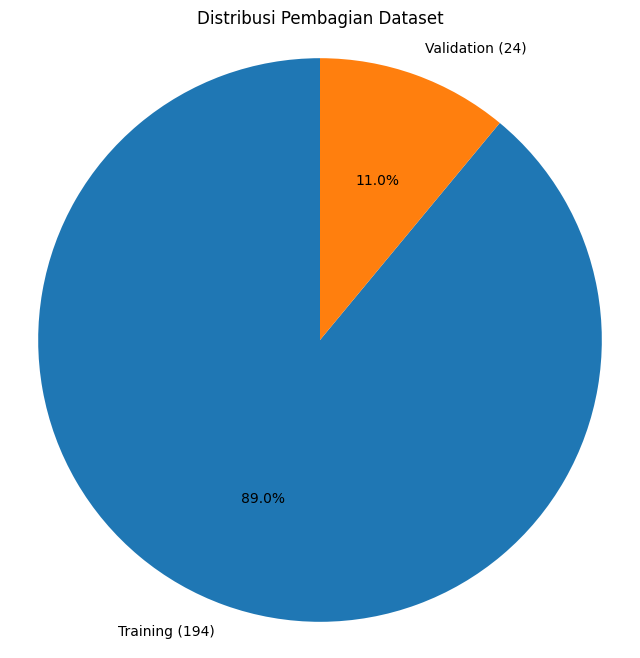

In [ ]:
import matplotlib.pyplot as plt

# DATA

train_count = len(train_files)
val_count   = len(val_files)

sizes = [train_count, val_count]

labels = [
    f'Training ({train_count})',
    f'Validation ({val_count})'
]

# PIE CHART

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Pembagian Dataset')

plt.axis('equal')

plt.show()

In [ ]:
# # Menggunakan seluruh data

# import os
# from tqdm import tqdm
# from sklearn.model_selection import train_test_split
# from monai.data import CacheDataset

# def list_case_dirs(root_dir: str):
#     if not os.path.isdir(root_dir):
#         raise FileNotFoundError(f"Folder tidak ditemukan: {root_dir}")
#     cases = [c for c in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, c))]
#     cases.sort()
#     return cases

# def make_file_dicts(base_dir: str, case_list, expect_label=None):
#     file_dicts = []
#     skipped = 0
#     for case in tqdm(case_list, desc=f"Building list ({os.path.basename(base_dir)})"):
#         case_dir = os.path.join(base_dir, case)
#         if not os.path.isdir(case_dir):
#             skipped += 1
#             continue

#         entry = {}
#         ok = True
#         for mod in modalities:
#             p = os.path.join(case_dir, f"{case}-{mod}.nii.gz")
#             if not os.path.exists(p):
#                 ok = False
#                 break
#             entry[mod] = p
#         if not ok:
#             skipped += 1
#             continue

#         seg_path = os.path.join(case_dir, f"{case}-seg.nii.gz")
#         has_label = os.path.exists(seg_path)

#         if expect_label is True and not has_label:
#             skipped += 1
#             continue

#         if has_label:
#             entry["label"] = seg_path

#         file_dicts.append(entry)

#     return file_dicts, skipped

# def split_labeled_unlabeled(*datasets):
#     labeled, unlabeled = [], []
#     for ds in datasets:
#         for x in ds:
#             (labeled if "label" in x else unlabeled).append(x)
#     return labeled, unlabeled

# train_cases = list_case_dirs(TRAIN_DIR)
# val_cases   = list_case_dirs(VAL_DIR)

# train_files_all, skipped_train = make_file_dicts(TRAIN_DIR, train_cases, expect_label=None)
# val_files_all,   skipped_val   = make_file_dicts(VAL_DIR,   val_cases,   expect_label=None)

# labeled_files, infer_files = split_labeled_unlabeled(train_files_all, val_files_all)

# train_files, internal_val_files = train_test_split(
#     labeled_files,
#     test_size=internal_val_ratio,
#     random_state=seed,
#     shuffle=True
# )

# print("\n===== DATA SPLIT SUMMARY =====")
# print(f"TRAIN_DIR cases               : {len(train_cases)} (skipped: {skipped_train})")
# print(f"VAL_DIR cases                 : {len(val_cases)} (skipped: {skipped_val})")
# print(f"Labeled total (trainable)     : {len(labeled_files)}")
# print(f"Unlabeled total (infer)       : {len(infer_files)}")
# print(f"Split -> Train: {len(train_files)} | Internal Val: {len(internal_val_files)}")

# def get_dataset(mode="train", cache_rate=0.15, num_workers=2):
#     if mode == "train":
#         data, transform = train_files, train_transforms
#     elif mode == "val":
#         data, transform = internal_val_files, val_transforms
#     elif mode == "infer":
#         data, transform = infer_files, infer_transforms
#     else:
#         raise ValueError("Mode harus: 'train', 'val', atau 'infer'")

#     return CacheDataset(
#         data=data,
#         transform=transform,
#         cache_rate=cache_rate,
#         num_workers=num_workers
#     )

# print(" get_dataset() ready: train/val dari labeled, infer dari unlabeled.")


##Dataset & DataLoader

In [ ]:
# from collections import Counter
# import torch
# import warnings
# warnings.filterwarnings("ignore")

# def analyze_label_distribution_transformed(ds, num_samples=50, num_classes=5, include_background=True):
#     counts = Counter()
#     n = min(len(ds), num_samples)

#     for i in range(n):
#         item = ds[i]

#         if isinstance(item, list):
#             labels = [x["label"] for x in item]
#         else:
#             y = item["label"]
#             if isinstance(y, torch.Tensor) and y.ndim >= 4 and y.shape[0] > 1:
#                 labels = [y[j] for j in range(y.shape[0])]
#             else:
#                 labels = [y]

#         for y in labels:
#             y = torch.as_tensor(y).detach().cpu().long()
#             uniq, c = torch.unique(y, return_counts=True)
#             for u, v in zip(uniq.tolist(), c.tolist()):
#                 if 0 <= u < num_classes:
#                     counts[u] += int(v)

#     if not include_background:
#         counts.pop(0, None)

#     total = sum(counts.values())
#     print(f"Checked {n} dataset items")
#     for cls in range(num_classes):
#         if not include_background and cls == 0:
#             continue
#         freq = (counts.get(cls, 0) / total * 100.0) if total > 0 else 0.0
#         print(f"Class {cls}: {counts.get(cls, 0)} voxels ({freq:.2f}%)")

# train_ds = get_dataset("train")
# analyze_label_distribution_transformed(train_ds, num_samples=50, num_classes=5, include_background=True)


In [ ]:
# from collections import Counter
# import warnings
# warnings.filterwarnings("ignore")

# def analyze_patch_presence(ds, num_items=200, num_classes=5):
#     present = Counter()
#     total_patches = 0

#     n = min(len(ds), num_items)
#     for i in range(n):
#         item = ds[i]
#         patches = item if isinstance(item, list) else [item]

#         for p in patches:
#             y = p["label"]
#             if y.ndim == 4 and y.shape[0] == 1:
#                 y = y[0]
#             uniq = torch.unique(y).tolist()

#             for c in range(num_classes):
#                 if c in uniq:
#                     present[c] += 1
#             total_patches += 1

#     print(f"Checked {n} dataset items => total patches: {total_patches}")
#     for c in range(num_classes):
#         print(f"Class {c}: present in {present[c]} patches ({present[c]/max(1,total_patches)*100:.2f}%)")

# train_ds = get_dataset("train")
# analyze_patch_presence(train_ds, num_items=50, num_classes=5)


In [ ]:
import torch
from monai.data import DataLoader

train_ds = get_dataset("train")
val_ds   = get_dataset("val")
test_ds  = get_dataset("test")

def keep_as_is_collate(batch):
    return batch

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=keep_as_is_collate,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
    prefetch_factor=2,
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
    prefetch_factor=2,
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
    prefetch_factor=2,
)

Loading dataset: 100%|██████████| 2/2 [00:08<00:00,  4.30s/it]


In [ ]:
import nibabel as nib
import numpy as np
import torch
from collections import Counter


def compute_class_weights(
    file_dicts,
    num_classes=5,
    method="median",
    power=0.5,
    clamp=(0.05, 0.7),
    ignore_background=True,
    eps=1e-6
):
    """
    Menghitung class weights untuk segmentation berdasarkan distribusi voxel.

    Parameters
    ----------
    file_dicts : list of dict
        List berisi path ke file (harus memiliki key "label").
    num_classes : int
        Jumlah total kelas (termasuk background).
    method : str
        Metode weighting:
        - "inverse": 1 / freq^power
        - "median": median(freq) / freq (lebih stabil)
    power : float
        Digunakan pada metode inverse.
    clamp : tuple(float, float)
        Batas minimum dan maksimum bobot untuk stabilitas training.
    ignore_background : bool
        Jika True, background (class 0) tidak digunakan dalam perhitungan utama.
    eps : float
        Nilai kecil untuk menghindari pembagian nol.

    Returns
    -------
    torch.Tensor
        Tensor bobot kelas dengan ukuran [num_classes].
    """

    counts = Counter()

    for item in file_dicts:
        if "label" not in item:
            continue

        label = nib.load(item["label"]).get_fdata().astype(np.int32)

        unique, count = np.unique(label, return_counts=True)
        for u, c in zip(unique.tolist(), count.tolist()):
            if 0 <= u < num_classes:
                counts[u] += int(c)

    total_voxels = sum(counts.values())

    freqs = np.array([
        counts[i] / total_voxels if total_voxels > 0 else 0.0
        for i in range(num_classes)
    ], dtype=np.float64)

    if ignore_background:
        freqs[0] = 0.0

    freqs = np.maximum(freqs, eps)

    if method == "inverse":
        weights = 1.0 / (freqs ** power)
    elif method == "median":
        valid = freqs[freqs > eps]
        median = np.median(valid) if len(valid) > 0 else 1.0
        weights = median / freqs
    else:
        raise ValueError("method harus 'inverse' atau 'median'")

    weights = weights / weights.sum()

    weights = np.clip(weights, clamp[0], clamp[1])
    weights = weights / weights.sum()

    if ignore_background:
        weights[0] = 0.01
        weights = weights / weights.sum()

    return torch.tensor(weights, dtype=torch.float32)


num_classes = 5

if "train_files" in globals():
    file_dicts_for_weights = train_files
elif "train_files_all" in globals():
    file_dicts_for_weights = train_files_all
elif "train_files_with_label" in globals():
    file_dicts_for_weights = train_files_with_label
else:
    raise NameError(
        "Dataset tidak ditemukan. Jalankan terlebih dahulu proses pembuatan file list."
    )


class_weights = compute_class_weights(
    file_dicts=file_dicts_for_weights,
    num_classes=num_classes,
    method="inverse",
    power=0.5,
    clamp=(0.05, 0.6),
    ignore_background=True
).to(device)


print("Class Weights:", class_weights)
print("Total Sum    :", class_weights.sum().item())

Class Weights: tensor([0.0385, 0.2404, 0.2404, 0.2404, 0.2404], device='cuda:0')
Total Sum    : 0.9999999403953552


In [ ]:
# from collections import Counter
# import torch

# def voxel_dist_after_cropping(ds, num_items=50, num_classes=5):
#     counts = Counter()
#     n = min(len(ds), num_items)
#     total_patches = 0

#     for i in range(n):
#         item = ds[i]
#         patches = item if isinstance(item, list) else [item]

#         for p in patches:
#             y = torch.as_tensor(p["label"]).detach().cpu().long()
#             uniq, c = torch.unique(y, return_counts=True)
#             for u, v in zip(uniq.tolist(), c.tolist()):
#                 if 0 <= u < num_classes:
#                     counts[u] += int(v)
#             total_patches += 1

#     total_vox = sum(counts.values())
#     print(f"Checked {n} items => total patches: {total_patches}")
#     for cls in range(num_classes):
#         pct = (counts.get(cls, 0) / total_vox * 100.0) if total_vox > 0 else 0.0
#         print(f"Class {cls}: {counts.get(cls,0)} voxels ({pct:.4f}%)")

# train_ds = get_dataset("train")
# voxel_dist_after_cropping(train_ds, num_items=50, num_classes=5)


In [ ]:
import torch

print("Jumlah sample dalam train_ds:", len(train_ds))

sample = train_ds[0]

def summarize_patch(p, idx=None):
    prefix = f"Patch {idx} | " if idx is not None else ""
    print(prefix + "keys:", list(p.keys()))
    for k, v in p.items():
        if torch.is_tensor(v):
            vmin = float(v.min().cpu())
            vmax = float(v.max().cpu())
            print(f"  {k:>10} : shape={tuple(v.shape)} | dtype={v.dtype} | min={vmin:.3f} | max={vmax:.3f}")
        else:
            print(f"  {k:>10} : type={type(v)}")

    if "label" in p:
        uniq = torch.unique(p["label"]).cpu().tolist()
        print("  unique(label):", uniq)

    if "image_t1" in p and "image_t2" in p:
        print("  image_t1:", tuple(p["image_t1"].shape))
        print("  image_t2:", tuple(p["image_t2"].shape))

if isinstance(sample, list):
    print(f"Sample ini berisi {len(sample)} patch (num_samples dari RandCropByPosNegLabeld).")
    for j, patch in enumerate(sample):
        summarize_patch(patch, idx=j)
else:
    summarize_patch(sample)

print("\nCek 5 sample pertama (unique labels patch-0):")
for i in range(min(5, len(train_ds))):
    s = train_ds[i]
    if isinstance(s, list):
        s0 = s[0]
    else:
        s0 = s
    uniq = torch.unique(s0["label"]).cpu().tolist()
    print(f"Sample {i}: unique labels = {uniq}")

print("\n Sanity check selesai.")


Jumlah sample dalam train_ds: 194
Sample ini berisi 7 patch (num_samples dari RandCropByPosNegLabeld).
Patch 0 | keys: ['image_t1', 'image_t2', 'label']
    image_t1 : shape=(2, 128, 128, 128) | dtype=torch.float32 | min=0.000 | max=1.000
    image_t2 : shape=(2, 128, 128, 128) | dtype=torch.float32 | min=0.000 | max=1.000
       label : shape=(1, 128, 128, 128) | dtype=torch.int64 | min=0.000 | max=4.000
  unique(label): [0, 2, 3, 4]
  image_t1: (2, 128, 128, 128)
  image_t2: (2, 128, 128, 128)
Patch 1 | keys: ['image_t1', 'image_t2', 'label']
    image_t1 : shape=(2, 128, 128, 128) | dtype=torch.float32 | min=0.000 | max=1.000
    image_t2 : shape=(2, 128, 128, 128) | dtype=torch.float32 | min=0.000 | max=1.000
       label : shape=(1, 128, 128, 128) | dtype=torch.int64 | min=0.000 | max=4.000
  unique(label): [0, 2, 3, 4]
  image_t1: (2, 128, 128, 128)
  image_t2: (2, 128, 128, 128)
Patch 2 | keys: ['image_t1', 'image_t2', 'label']
    image_t1 : shape=(2, 128, 128, 128) | dtype=tor

## Arsitektur Model CKD-TransBTS



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def window_partition(x, ws):
    B, C, H, W, D = x.shape
    pad_h = (ws - H % ws) % ws
    pad_w = (ws - W % ws) % ws
    pad_d = (ws - D % ws) % ws

    x = F.pad(x, (0, pad_d, 0, pad_w, 0, pad_h))
    Hp, Wp, Dp = H + pad_h, W + pad_w, D + pad_d

    x = x.view(B, C,
               Hp // ws, ws,
               Wp // ws, ws,
               Dp // ws, ws)
    x = x.permute(0,2,4,6,1,3,5,7).contiguous()

    return x.view(-1, C, ws, ws, ws), (H, W, D)


def window_reverse(x, ws, original_shape):
    H, W, D = original_shape
    Hp = (H + ws - 1) // ws * ws
    Wp = (W + ws - 1) // ws * ws
    Dp = (D + ws - 1) // ws * ws

    B = int(x.shape[0] / (Hp * Wp * Dp / ws**3))

    x = x.view(B,
               Hp // ws,
               Wp // ws,
               Dp // ws,
               -1,
               ws, ws, ws)

    x = x.permute(0,4,1,5,2,6,3,7).contiguous()
    x = x.view(B, -1, Hp, Wp, Dp)

    return x[:, :, :H, :W, :D]


def flatten_3d(x):
    return x.flatten(2).transpose(1, 2)


def unflatten_3d(x, H, W, D):
    return x.transpose(1, 2).view(x.shape[0], -1, H, W, D)


class CrossAttention(nn.Module):
    def __init__(self, dim, heads=2):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)

    def forward(self, q, k, v):
        out, _ = self.attn(q, k, v)
        return out


class MSA(nn.Module):
    def __init__(self, dim, heads=2):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return out


class MBConv(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(dim, dim * 2, 1),
            nn.GELU(),
            nn.Conv3d(dim * 2, dim * 2, 3, padding=1, groups=dim * 2),
            nn.GELU(),
            nn.Conv3d(dim * 2, dim, 1),
        )

    def forward(self, x):
        return self.block(x)


class SelfModalBlock(nn.Module):
    def __init__(self, dim, ws=4):
        super().__init__()
        self.ws = ws
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MSA(dim)
        self.norm2 = nn.InstanceNorm3d(dim)
        self.mbconv = MBConv(dim)

    def forward(self, x):
        xw, shape = window_partition(x, self.ws)

        t = flatten_3d(xw)
        shortcut_t = t

        t = self.norm1(t)
        t = self.attn(t)
        t = t + shortcut_t

        xw = unflatten_3d(t, self.ws, self.ws, self.ws)
        x = window_reverse(xw, self.ws, shape)

        shortcut = x

        x = self.norm2(x)
        x = self.mbconv(x)
        x = x + shortcut

        return x


class CrossModalBlock(nn.Module):
    def __init__(self, dim, ws=4):
        super().__init__()
        self.ws = ws
        self.norm = nn.LayerNorm(dim)
        self.cross_attn = CrossAttention(dim)

    def forward(self, x1, x2):
        shift = self.ws // 2
        x1 = torch.roll(x1, (-shift, -shift, -shift), dims=(2, 3, 4))
        x2 = torch.roll(x2, (-shift, -shift, -shift), dims=(2, 3, 4))

        x1w, shape1 = window_partition(x1, self.ws)
        x2w, shape2 = window_partition(x2, self.ws)

        t1 = flatten_3d(x1w)
        t2 = flatten_3d(x2w)

        s1 = t1
        s2 = t2

        t1 = self.norm(t1)
        t2 = self.norm(t2)

        mt1 = self.cross_attn(t1, t2, t2)
        mt2 = self.cross_attn(t2, t1, t1)

        t1 = t1 + mt1 + s1
        t2 = t2 + mt2 + s2

        x1 = unflatten_3d(t1, self.ws, self.ws, self.ws)
        x2 = unflatten_3d(t2, self.ws, self.ws, self.ws)

        x1 = window_reverse(x1, self.ws, shape1)
        x2 = window_reverse(x2, self.ws, shape2)

        return x1, x2


class MCCA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.self1 = SelfModalBlock(dim)
        self.self2 = SelfModalBlock(dim)
        self.cross = CrossModalBlock(dim)

    def forward(self, x1, x2):
        x1 = self.self1(x1)
        x2 = self.self2(x2)
        x1, x2 = self.cross(x1, x2)
        return x1, x2


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_c, out_c, 3, padding=1),
            nn.InstanceNorm3d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_c, out_c, 3, padding=1),
            nn.InstanceNorm3d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConvStem(nn.Module):
    def __init__(self, in_c=1, base_c=16):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv3d(in_c, base_c, 3, stride=2, padding=1),
            nn.InstanceNorm3d(base_c),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(base_c, base_c * 2, 3, stride=2, padding=1),
            nn.InstanceNorm3d(base_c * 2),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        c1 = self.conv1(x)
        c2 = self.conv2(c1)
        return c1, c2


class SEBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // 4),
            nn.ReLU(inplace=True),
            nn.Linear(c // 4, c),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1, 1)
        return x * w


class Bottleneck(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block1 = ConvBlock(dim, dim)
        self.block2 = ConvBlock(dim, dim)
        self.se = SEBlock(dim)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.se(x)
        return x


class TCFC(nn.Module):
    def __init__(self, in_c, skip_c):
        super().__init__()

        self.proj_x = nn.Conv3d(in_c, in_c, 1)
        self.proj_s = nn.Conv3d(skip_c, in_c, 1)

        self.conv_xyz = nn.Conv3d(in_c * 3, in_c, 3, padding=1)
        self.conv_attn = nn.Conv3d(in_c, in_c, 1)

        self.sigmoid = nn.Sigmoid()

        self.fuse = nn.Sequential(
            nn.Conv3d(in_c * 2, in_c, 3, padding=1),
            nn.InstanceNorm3d(in_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="trilinear", align_corners=False)

        x = self.proj_x(x)
        s = self.proj_s(skip)

        f = x + s

        fx = torch.mean(f, dim=2, keepdim=True)
        fy = torch.mean(f, dim=3, keepdim=True)
        fz = torch.mean(f, dim=4, keepdim=True)

        fx = fx.expand_as(f)
        fy = fy.expand_as(f)
        fz = fz.expand_as(f)

        f_xyz = torch.cat([fx, fy, fz], dim=1)

        attn = self.conv_xyz(f_xyz)
        attn = self.conv_attn(attn)
        attn = self.sigmoid(attn)

        x_out = x * attn + x
        s_out = s * attn + s

        out = torch.cat([x_out, s_out], dim=1)
        out = self.fuse(out)

        return out


class CKD_TransBTS(nn.Module):
    def __init__(self, num_classes=5, base_c=16):
        super().__init__()

        self.cs_t1c = ConvStem(1, base_c)
        self.cs_t1n = ConvStem(1, base_c)
        self.cs_t2f = ConvStem(1, base_c)
        self.cs_t2w = ConvStem(1, base_c)

        self.t1_reduce = nn.Conv3d(base_c * 4, base_c * 2, 1)
        self.t2_reduce = nn.Conv3d(base_c * 4, base_c * 2, 1)

        self.mcca1 = MCCA(base_c * 2)
        self.mcca2 = MCCA(base_c * 2)
        self.mcca3 = MCCA(base_c * 2)

        self.bottleneck = Bottleneck(base_c * 4)

        self.up3 = nn.ConvTranspose3d(base_c * 4, base_c * 2, 2, 2)
        self.up2 = nn.ConvTranspose3d(base_c * 2, base_c * 2, 2, 2)

        self.tcfc3 = TCFC(base_c * 2, base_c * 2)
        self.tcfc2 = TCFC(base_c * 2, base_c * 2)

        self.skip_l2_reduce = nn.Conv3d(base_c * 4, base_c * 2, 1)
        self.skip_l1_reduce = nn.Conv3d(base_c * 4, base_c * 2, 1)
        self.skip_reduce = nn.Conv3d(base_c * 4, base_c * 2, 1)

        self.conv_dec1 = ConvBlock(base_c * 2, base_c * 2)
        self.conv_dec2 = ConvBlock(base_c * 2, base_c * 2)

        self.final_conv1 = nn.Conv3d(base_c * 2, base_c * 2, 3, padding=1)
        self.final_norm1 = nn.InstanceNorm3d(base_c * 2)

        self.final_conv2 = nn.Conv3d(base_c * 2, num_classes, 3, padding=1)

    def forward(self, t1c, t1n, t2f, t2w):

        t1c_s, t1c_f = self.cs_t1c(t1c)
        t1n_s, t1n_f = self.cs_t1n(t1n)
        t2f_s, t2f_f = self.cs_t2f(t2f)
        t2w_s, t2w_f = self.cs_t2w(t2w)

        t1 = torch.cat([t1c_f, t1n_f], dim=1)
        t2 = torch.cat([t2f_f, t2w_f], dim=1)

        t1 = self.t1_reduce(t1)
        t2 = self.t2_reduce(t2)

        t1_l1, t2_l1 = self.mcca1(t1, t2)
        t1_l2, t2_l2 = self.mcca2(t1_l1, t2_l1)
        t1_l3, t2_l3 = self.mcca3(t1_l2, t2_l2)

        x = torch.cat([t1_l3, t2_l3], dim=1)
        x = self.bottleneck(x)

        x = self.up3(x)

        skip1 = torch.cat([t1_l2, t2_l2], dim=1)
        skip1 = self.skip_l2_reduce(skip1)
        x = self.tcfc3(x, skip1)

        x = self.conv_dec1(x)

        x = self.up2(x)

        skip2 = torch.cat([t1_l1, t2_l1], dim=1)
        skip2 = self.skip_l1_reduce(skip2)
        x = self.tcfc2(x, skip2)

        x = self.conv_dec2(x)

        skip0 = torch.cat([t1c_s, t1n_s, t2f_s, t2w_s], dim=1)
        skip0 = self.skip_reduce(skip0)

        if x.shape[2:] != skip0.shape[2:]:
            x = F.interpolate(x, size=skip0.shape[2:], mode="trilinear", align_corners=False)

        x = x + skip0

        x = F.relu(self.final_norm1(self.final_conv1(x)))
        x = self.final_conv2(x)

        return x

In [ ]:
import torch
import torch.nn as nn

# INIT MODEL
model = CKD_TransBTS(
    num_classes=5,
    base_c=16
)

print("model built:", type(model).__name__)

model built: CKD_TransBTS


##  Loss Function


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BoundaryLoss(nn.Module):
    def __init__(self, include_background: bool = False):
        super().__init__()
        self.include_background = bool(include_background)

    def forward(self, logits: torch.Tensor, target_onehot: torch.Tensor) -> torch.Tensor:
        probs = torch.softmax(logits, dim=1)
        sdf = self._compute_sdf_batch(target_onehot)
        return (torch.abs(probs - target_onehot) * torch.abs(sdf)).mean()

    @torch.no_grad()
    def _compute_sdf_batch(self, target_onehot: torch.Tensor) -> torch.Tensor:
        try:
            from scipy.ndimage import distance_transform_edt
        except Exception as e:
            raise RuntimeError("BoundaryLoss membutuhkan scipy. Install: `pip install scipy`.") from e

        device = target_onehot.device
        sdf = torch.zeros_like(target_onehot, dtype=torch.float32, device=device)

        B, C, _, _, _ = target_onehot.shape
        for b in range(B):
            for c in range(C):
                if (c == 0) and (not self.include_background):
                    continue
                mask = target_onehot[b, c].detach().cpu().numpy().astype(bool)
                if mask.any():
                    negmask = ~mask
                    dist_out = distance_transform_edt(negmask)
                    dist_in = distance_transform_edt(mask)
                    sdf[b, c] = torch.from_numpy(dist_out - dist_in).to(device=device, dtype=torch.float32)
        return sdf


class CombinedLoss(nn.Module):
    def __init__(
        self,
        ce_weight: float = 0.5,
        dice_weight: float = 1.0,
        aux_weight: float = 0.2,
        class_weights: torch.Tensor | None = None,
        exclude_background: bool = True,
        generalized_dice: bool = True,
        smooth: float = 1e-5,
        boundary_loss_fn: nn.Module | None = None,
        boundary_weight: float = 0.0,
        boundary_warmup_epoch: int = 10,
        boundary_ramp_epochs: int = 5,
        dice_warmup_epochs: int = 0,
    ):
        super().__init__()
        self.ce_weight = float(ce_weight)
        self.dice_weight = float(dice_weight)
        self.aux_weight = float(aux_weight)

        self.class_weights = class_weights
        self.exclude_background = bool(exclude_background)
        self.generalized_dice = bool(generalized_dice)
        self.smooth = float(smooth)

        self.boundary_loss_fn = boundary_loss_fn
        self.boundary_weight_final = float(boundary_weight)
        self.boundary_warmup_epoch = int(boundary_warmup_epoch)
        self.boundary_ramp_epochs = int(boundary_ramp_epochs)

        self.dice_warmup_epochs = int(dice_warmup_epochs)

        self.dice_w = 1.0
        self.boundary_active = False
        self.boundary_w = 0.0

    @torch.no_grad()
    def set_epoch(self, epoch: int):
        if self.dice_warmup_epochs <= 0:
            self.dice_w = 1.0
        else:
            t = (epoch + 1) / float(self.dice_warmup_epochs)
            t = float(min(1.0, max(0.0, t)))
            self.dice_w = 0.1 + 0.9 * t

        if (self.boundary_loss_fn is None) or (self.boundary_weight_final <= 0.0):
            self.boundary_active = False
            self.boundary_w = 0.0
            return

        if epoch < self.boundary_warmup_epoch:
            self.boundary_active = False
            self.boundary_w = 0.0
            return

        self.boundary_active = True
        if self.boundary_ramp_epochs <= 0:
            self.boundary_w = self.boundary_weight_final
        else:
            t = (epoch - self.boundary_warmup_epoch + 1) / float(self.boundary_ramp_epochs)
            t = float(min(1.0, max(0.0, t)))
            self.boundary_w = self.boundary_weight_final * t

    def _prep(self, logits: torch.Tensor, y_true: torch.Tensor):
        if y_true.ndim == 5 and y_true.shape[1] == 1:
            y_true = y_true[:, 0]
        y_true_cls = y_true.long()

        if logits.shape[2:] != y_true_cls.shape[1:]:
            logits = F.interpolate(logits, size=y_true_cls.shape[1:], mode="trilinear", align_corners=False)

        C = logits.shape[1]

        if (y_true_cls.min().item() < 0) or (y_true_cls.max().item() >= C):
            raise ValueError(
                f"Label out of range untuk num_classes={C}. "
                f"Found min={int(y_true_cls.min().item())}, max={int(y_true_cls.max().item())}."
            )

        y_true_1h = F.one_hot(y_true_cls, num_classes=C).permute(0, 4, 1, 2, 3).float()
        return logits, y_true_cls, y_true_1h

    def _dice_loss(self, logits: torch.Tensor, target_onehot: torch.Tensor) -> torch.Tensor:
        probs = torch.softmax(logits, dim=1)
        dims = (0, 2, 3, 4)

        if self.exclude_background and probs.shape[1] > 1:
            probs = probs[:, 1:]
            target_onehot = target_onehot[:, 1:]

        inter = torch.sum(probs * target_onehot, dim=dims)
        denom = torch.sum(probs + target_onehot, dim=dims)
        dice = (2.0 * inter + self.smooth) / (denom + self.smooth)

        if self.generalized_dice:
            gt_vol = torch.sum(target_onehot, dim=dims)
            w = 1.0 / (gt_vol * gt_vol + self.smooth)
            dice_g = (w * dice).sum() / (w.sum() + self.smooth)
            return 1.0 - dice_g
        return 1.0 - dice.mean()

    def _single(self, logits: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        logits, y_true_cls, y_true_1h = self._prep(logits, y_true)

        if self.class_weights is not None:
            if self.class_weights.ndim != 1 or self.class_weights.numel() != logits.shape[1]:
                raise ValueError(
                    f"class_weights harus shape [C]={logits.shape[1]}, "
                    f"tapi dapat {tuple(self.class_weights.shape)}."
                )
            cw = self.class_weights.to(device=logits.device, dtype=torch.float32)
        else:
            cw = None

        loss_ce = F.cross_entropy(logits, y_true_cls, weight=cw)
        loss_dice = self._dice_loss(logits, y_true_1h)

        total = (self.dice_w * self.dice_weight) * loss_dice + self.ce_weight * loss_ce

        if self.boundary_active and (self.boundary_w > 0.0):
            total = total + self.boundary_w * self.boundary_loss_fn(logits, y_true_1h)

        return total

    def forward(self, y_pred, y_true):
        if isinstance(y_pred, dict):
            main = self._single(y_pred["main"], y_true)
            aux_list = y_pred.get("aux", [])
            if len(aux_list) > 0:
                aux_losses = [self._single(a, y_true) for a in aux_list]
                aux_mean = torch.stack(aux_losses).mean()
                return main + self.aux_weight * aux_mean
            return main
        return self._single(y_pred, y_true)


## Metrics (Dice Score per Class)
Untuk menghitung kualitas segmentasi tiap kelas.

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

from scipy.ndimage import binary_erosion, distance_transform_edt
from monai.inferers import sliding_window_inference
from tqdm import tqdm


def safe_mean(arr):
    arr = [x for x in arr if not np.isnan(x)]
    if len(arr) == 0:
        return np.nan
    return float(np.mean(arr))


def _dice_binary(pred, true, eps=1e-5):

    pred = pred.astype(bool)
    true = true.astype(bool)

    pred_sum = pred.sum()
    true_sum = true.sum()

    if pred_sum == 0 and true_sum == 0:
        return 1.0

    if pred_sum == 0 or true_sum == 0:
        return 0.0

    inter = np.logical_and(pred, true).sum()

    return float(
        (2.0 * inter + eps) /
        (pred_sum + true_sum + eps)
    )


def _sensitivity_binary(pred, true, eps=1e-5):

    pred = pred.astype(bool)
    true = true.astype(bool)

    tp = np.logical_and(pred, true).sum()
    fn = np.logical_and(~pred, true).sum()

    if tp == 0 and fn == 0:
        return 1.0

    return float(
        (tp + eps) /
        (tp + fn + eps)
    )


def _hd95_3d(pred, true, spacing=(1.0,1.0,1.0)):

    pred = pred.astype(bool)
    true = true.astype(bool)

    if pred.sum() == 0 and true.sum() == 0:
        return 0.0

    if pred.sum() == 0 or true.sum() == 0:
        return np.nan

    pred_surface = np.logical_xor(
        pred,
        binary_erosion(pred, border_value=1)
    )

    true_surface = np.logical_xor(
        true,
        binary_erosion(true, border_value=1)
    )

    if not pred_surface.any() or not true_surface.any():
        return np.nan

    dt_true = distance_transform_edt(
        ~true_surface,
        sampling=spacing
    )

    dt_pred = distance_transform_edt(
        ~pred_surface,
        sampling=spacing
    )

    d_pred_true = dt_true[pred_surface]
    d_true_pred = dt_pred[true_surface]

    all_dist = np.concatenate([
        d_pred_true,
        d_true_pred
    ])

    return float(np.percentile(all_dist, 95))


@torch.no_grad()
def evaluate_segmentation(
    loader,
    model,
    device,
    roi_size=roi_size,
    spacing=(1.0,1.0,1.0)
):

    def model_wrapper(x):

        return model(
            x[:,0:1],
            x[:,1:2],
            x[:,2:3],
            x[:,3:4]
        )

    model.eval()

    class_names = [
        "ET",
        "NETC",
        "SNFH",
        "RC"
    ]

    per_class = {
        c: {
            "dice": [],
            "sens": [],
            "hd95": []
        }
        for c in class_names
    }

    brats_regions = {
        "ET": {
            "dice": [],
            "sens": [],
            "hd95": []
        },
        "TC": {
            "dice": [],
            "sens": [],
            "hd95": []
        },
        "WT": {
            "dice": [],
            "sens": [],
            "hd95": []
        },
    }

    for batch in tqdm(val_loader, desc="Evaluating", ncols=100):

        image_t1 = batch["image_t1"].to(device)
        image_t2 = batch["image_t2"].to(device)
        labels   = batch["label"].to(device)

        if image_t1.ndim == 4:
            image_t1 = image_t1.unsqueeze(0)

        if image_t2.ndim == 4:
            image_t2 = image_t2.unsqueeze(0)

        if labels.ndim == 4:
            labels = labels.unsqueeze(0)

        if labels.ndim == 5 and labels.shape[1] == 1:
            labels = labels[:,0]

        labels = labels.long()

        x = torch.cat([
            image_t1[:,0:1],
            image_t1[:,1:2],
            image_t2[:,0:1],
            image_t2[:,1:2],
        ], dim=1)

        outputs = sliding_window_inference(
            inputs=x,
            roi_size=roi_size,
            sw_batch_size=1,
            predictor=model_wrapper,
            overlap=0.6,
            mode="gaussian"
        )

        if outputs.shape[2:] != labels.shape[1:]:

            outputs = F.interpolate(
                outputs,
                size=labels.shape[1:],
                mode="trilinear",
                align_corners=False
            )

        pred_lbl = torch.argmax(outputs, dim=1)

        pred_np = pred_lbl.cpu().numpy().astype(np.uint8)
        true_np = labels.cpu().numpy().astype(np.uint8)

        B = pred_np.shape[0]

        for b in range(B):

            p = pred_np[b]
            t = true_np[b]

            # PER CLASS

            for idx, cname in enumerate(class_names, start=1):

                p_c = (p == idx)
                t_c = (t == idx)

                d = _dice_binary(p_c, t_c)
                s = _sensitivity_binary(p_c, t_c)
                h = _hd95_3d(p_c, t_c, spacing)

                per_class[cname]["dice"].append(d)
                per_class[cname]["sens"].append(s)

                if not np.isnan(h):
                    per_class[cname]["hd95"].append(h)

            # BRATS REGIONS

            # ET
            p_et = (p == 1)
            t_et = (t == 1)

            # TC
            p_tc = (p == 1) | (p == 2)
            t_tc = (t == 1) | (t == 2)

            # WT
            p_wt = (p == 1) | (p == 2) | (p == 3)
            t_wt = (t == 1) | (t == 2) | (t == 3)

            regions = {
                "ET": (p_et, t_et),
                "TC": (p_tc, t_tc),
                "WT": (p_wt, t_wt),
            }

            for rname, (pp, tt) in regions.items():

                d = _dice_binary(pp, tt)
                s = _sensitivity_binary(pp, tt)
                h = _hd95_3d(pp, tt, spacing)

                brats_regions[rname]["dice"].append(d)
                brats_regions[rname]["sens"].append(s)

                if not np.isnan(h):
                    brats_regions[rname]["hd95"].append(h)

    results = {
        "global": {},
        "regions": {},
        "per_class": {}
    }

    # GLOBAL

    global_dice = []
    global_sens = []
    global_hd95 = []

    for cname in class_names:

        d = safe_mean(per_class[cname]["dice"])
        s = safe_mean(per_class[cname]["sens"])
        h = safe_mean(per_class[cname]["hd95"])

        global_dice.append(d)
        global_sens.append(s)
        global_hd95.append(h)

    results["global"] = {
        "dice": safe_mean(global_dice),
        "sens": safe_mean(global_sens),
        "hd95": safe_mean(global_hd95),
    }

    # PER CLASS

    for cname in class_names:

        results["per_class"][cname] = {
            "dice": safe_mean(per_class[cname]["dice"]),
            "sens": safe_mean(per_class[cname]["sens"]),
            "hd95": safe_mean(per_class[cname]["hd95"]),
        }

    # REGIONS

    for rname in brats_regions.keys():

        results["regions"][rname] = {
            "dice": safe_mean(brats_regions[rname]["dice"]),
            "sens": safe_mean(brats_regions[rname]["sens"]),
            "hd95": safe_mean(brats_regions[rname]["hd95"]),
        }

    return results

In [ ]:
# model = model.to(device)
# batch = next(iter(train_loader))
# patch = batch[0] if isinstance(batch, list) else batch  # kalau train_loader return list patches
# imgs_t1, imgs_t2, lbls = to_device(patch, device)
# out = model(imgs_t1, imgs_t2)
# print(out["main"].shape, len(out["aux"]))


## Train Model


In [ ]:
import gc
from google.colab import drive
from monai.inferers import sliding_window_inference
import warnings
warnings.filterwarnings("ignore")

NUM_EPOCHS    = 10
ACCUM_STEPS   = 2
MAX_GRAD_NORM = 1.0
BASE_LR       = 1e-3
WEIGHT_DECAY  = 1e-5

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

if USE_AMP:
    torch.set_float32_matmul_precision("high")

model = model.to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY
)

scaler = torch.amp.GradScaler(enabled=USE_AMP)

drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/CKD-Trans"
os.makedirs(SAVE_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    SAVE_DIR,
    "L1_checkpoint.pth"
)

LATEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "L1_latest.pth"
)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "L1_best_model.pth"
)

start_epoch = 1
best_dice   = 0.0
global_step = 0
total_training_time = 0

history = {
    "loss": [], "val_loss": [],
    "dice": [], "val_dice": [],
    "iou":  [], "val_iou":  []
}

if os.path.exists(CHECKPOINT_PATH):

    print("=" * 60)
    print("Checkpoint ditemukan")
    print("Melanjutkan training sebelumnya...")
    print("=" * 60)

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scaler.load_state_dict(
        checkpoint["scaler_state_dict"]
    )

    start_epoch = checkpoint["epoch"] + 1
    best_dice   = checkpoint["best_dice"]
    global_step = checkpoint["global_step"]
    total_training_time = checkpoint.get(
    "total_training_time", 0
    )

    history = checkpoint["history"]

    print(f"Resume dari epoch {start_epoch}")
    print(f"Best Dice sebelumnya = {best_dice:.4f}")

else:

    print("=" * 60)
    print("Checkpoint tidak ditemukan")
    print("Training dimulai dari awal")
    print("=" * 60)

class_weights = compute_class_weights(
    file_dicts=train_files,
    num_classes=5,
    method="inverse",
    power=0.5,
    clamp=(0.05, 0.6),
    ignore_background=True
).to(DEVICE)

criterion = CombinedLoss(
    ce_weight=0.5,
    dice_weight=0.7,
    class_weights=class_weights,
    generalized_dice=True,
    exclude_background=True
)


def flatten_batch(batch):
    if isinstance(batch, list):
        if isinstance(batch[0], list):
            return [p for sub in batch for p in sub]
        return batch
    return [batch]


def to_device(batch):
    x1 = batch["image_t1"]
    x2 = batch["image_t2"]
    y  = batch["label"]

    if x1.ndim == 4: x1 = x1.unsqueeze(0)
    if x2.ndim == 4: x2 = x2.unsqueeze(0)
    if y.ndim  == 4: y  = y.unsqueeze(0)

    x1 = x1.to(DEVICE)
    x2 = x2.to(DEVICE)
    y  = y.to(DEVICE)

    t1c = x1[:, 0:1]
    t1n = x1[:, 1:2]
    t2f = x2[:, 0:1]
    t2w = x2[:, 1:2]

    return t1c, t1n, t2f, t2w, y


def resize_pred(pred, y):
    if pred.shape[2:] != y.shape[2:]:
        pred = F.interpolate(pred, size=y.shape[2:], mode="trilinear", align_corners=False)
    return pred


def dice_coefficient(pred, target, eps=1e-6):
    pred   = torch.argmax(pred, dim=1)
    target = target.squeeze(1)

    dices = []
    for c in range(1, 5):
        p = (pred == c)
        t = (target == c)
        inter = (p & t).sum().float()
        denom = p.sum() + t.sum()
        if denom > 0:
            dices.append((2 * inter + eps) / (denom + eps))

    if len(dices) == 0:
        return torch.tensor(0.0, device=pred.device)
    return torch.mean(torch.stack(dices))


def mean_iou(pred, target, eps=1e-6):
    pred   = torch.argmax(pred, dim=1)
    target = target.squeeze(1)

    ious = []
    for c in range(1, 5):
        p = (pred == c)
        t = (target == c)
        inter = (p & t).sum().float()
        union = (p | t).sum().float()
        if union > 0:
            ious.append((inter + eps) / (union + eps))

    if len(ious) == 0:
        return torch.tensor(0.0, device=pred.device)
    return torch.mean(torch.stack(ious))


def model_inferer(t1c, t1n, t2f, t2w):
    def _forward(x):
        return model(x[:, 0:1], x[:, 1:2], x[:, 2:3], x[:, 3:4])

    img = torch.cat([t1c, t1n, t2f, t2w], dim=1)
    return sliding_window_inference(
        inputs=img,
        roi_size=roi_size,
        sw_batch_size=2,
        predictor=_forward,
        overlap=0.5,
        mode="gaussian"
    )


@torch.no_grad()
def evaluate(loader):
    model.eval()
    losses, dices, ious = [], [], []

    for batch in loader:
        t1c, t1n, t2f, t2w, y = to_device(batch)

        if y.sum() == 0:
            continue

        pred = model_inferer(t1c, t1n, t2f, t2w)
        pred = resize_pred(pred, y)

        loss = criterion(pred, y)
        losses.append(loss.item())
        dices.append(dice_coefficient(pred, y).item())
        ious.append(mean_iou(pred, y).item())

    if len(losses) == 0:
        return 0.0, 0.0, 0.0

    return np.mean(losses), np.mean(dices), np.mean(ious)


def gpu_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print(f"Training from epoch {start_epoch} to {NUM_EPOCHS}")

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    start_time = time.time()
    criterion.set_epoch(epoch - 1)

    model.train()
    optimizer.zero_grad(set_to_none=True)

    running_loss = 0.0
    train_dice   = []
    train_iou    = []
    step_count   = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", ncols=120)

    for batch in pbar:
        patches = flatten_batch(batch)

        for patch in patches:
            t1c, t1n, t2f, t2w, y = to_device(patch)

            if y.sum() == 0:
                if torch.rand(1).item() < 0.7:
                    continue

            with torch.autocast("cuda", enabled=USE_AMP):
                pred = model(t1c, t1n, t2f, t2w)
                pred = resize_pred(pred, y)
                loss = criterion(pred, y)

            if not torch.isfinite(loss):
                continue

            scaler.scale(loss / ACCUM_STEPS).backward()

            running_loss += loss.item()
            train_dice.append(dice_coefficient(pred, y).item())
            train_iou.append(mean_iou(pred, y).item())

            if (step_count + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1

            step_count += 1

        pbar.set_postfix({
            "loss": f"{running_loss/max(1,step_count):.4f}",
            "dice": f"{np.mean(train_dice) if train_dice else 0:.4f}"
        })

    if step_count == 0:
        print(f"Epoch {epoch}: skipped (no valid patches)")
        continue

    if step_count % ACCUM_STEPS != 0:
      scaler.unscale_(optimizer)

      torch.nn.utils.clip_grad_norm_(
          model.parameters(),
          MAX_GRAD_NORM
      )

      scaler.step(optimizer)
      scaler.update()
      optimizer.zero_grad(set_to_none=True)
      global_step += 1

    val_loss, val_dice, val_iou = evaluate(val_loader)

    epoch_loss = running_loss / step_count
    epoch_dice = np.mean(train_dice) if train_dice else 0.0
    epoch_iou  = np.mean(train_iou)  if train_iou  else 0.0

    history["loss"].append(epoch_loss)
    history["val_loss"].append(val_loss)
    history["dice"].append(epoch_dice)
    history["val_dice"].append(val_dice)
    history["iou"].append(epoch_iou)
    history["val_iou"].append(val_iou)

    epoch_time = int(time.time() - start_time)
    total_training_time += epoch_time

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(
        f"{epoch_time}s ━━━━━━━━━━━━━━━━━━━━ "
        f"- loss: {epoch_loss:.4f} "
        f"- dice_coefficient: {epoch_dice:.4f} "
        f"- mean_iou: {epoch_iou:.4f} "
        f"- val_loss: {val_loss:.4f} "
        f"- val_dice_coefficient: {val_dice:.4f} "
        f"- val_mean_iou: {val_iou:.4f}"
    )

    torch.save(
        model.state_dict(),
        LATEST_MODEL_PATH
    )

    if val_dice > best_dice:
        best_dice = val_dice

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"Best model saved (val_dice={val_dice:.4f})"
        )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_dice": best_dice,
            "global_step": global_step,
            "total_training_time": total_training_time,
            "history": history,
        },
        CHECKPOINT_PATH
    )

    gpu_cleanup()

print("Training completed")
print(f"Best val_dice: {best_dice:.4f}")
hours = total_training_time // 3600
minutes = (total_training_time % 3600) // 60
seconds = total_training_time % 60

print(
    f"Total training time: "
    f"{hours:02d}:{minutes:02d}:{seconds:02d}"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint ditemukan
Melanjutkan training sebelumnya...
Resume dari epoch 2
Best Dice sebelumnya = 0.2738
Training from epoch 2 to 10


Epoch 2/10: 100%|█████████████████████████████████████████████| 97/97 [17:01<00:00, 10.53s/it, loss=0.7943, dice=0.3393]



Epoch 2/10
1045s ━━━━━━━━━━━━━━━━━━━━ - loss: 0.7943 - dice_coefficient: 0.3393 - mean_iou: 0.2501 - val_loss: 0.7835 - val_dice_coefficient: 0.4087 - val_mean_iou: 0.3090
Best model saved (val_dice=0.4087)


Epoch 3/10: 100%|█████████████████████████████████████████████| 97/97 [16:58<00:00, 10.50s/it, loss=0.7852, dice=0.3584]



Epoch 3/10
1043s ━━━━━━━━━━━━━━━━━━━━ - loss: 0.7852 - dice_coefficient: 0.3584 - mean_iou: 0.2663 - val_loss: 0.7763 - val_dice_coefficient: 0.3586 - val_mean_iou: 0.2674


...


Epoch 8/10
1057s ━━━━━━━━━━━━━━━━━━━━ - loss: 0.7660 - dice_coefficient: 0.4159 - mean_iou: 0.3148 - val_loss: 0.7797 - val_dice_coefficient: 0.4214 - val_mean_iou: 0.3210


Epoch 9/10: 100%|█████████████████████████████████████████████| 97/97 [17:11<00:00, 10.63s/it, loss=0.7431, dice=0.3960]



Epoch 9/10
1055s ━━━━━━━━━━━━━━━━━━━━ - loss: 0.7431 - dice_coefficient: 0.3960 - mean_iou: 0.2983 - val_loss: 0.7761 - val_dice_coefficient: 0.3950 - val_mean_iou: 0.2941


Epoch 10/10: 100%|████████████████████████████████████████████| 97/97 [16:49<00:00, 10.41s/it, loss=0.6291, dice=0.3951]



Epoch 10/10
1034s ━━━━━━━━━━━━━━━━━━━━ - loss: 0.6291 - dice_coefficient: 0.3951 - mean_iou: 0.2997 - val_loss: 0.5762 - val_dice_coefficient: 0.4196 - val_mean_iou: 0.3149
Training completed
Best val_dice: 0.4452
Total training time: 03:06:48


In [ ]:
print(torch.unique(y))

tensor([0, 2, 3, 4], device='cuda:0')


In [ ]:
print(torch.unique(torch.argmax(pred, dim=1)))

tensor([0, 2, 3, 4], device='cuda:0')


In [ ]:
print(class_weights)

tensor([0.0385, 0.2404, 0.2404, 0.2404, 0.2404], device='cuda:0')


In [ ]:
with torch.no_grad():
    pred = model(t1c, t1n, t2f, t2w)
    pred_lbl = torch.argmax(pred, dim=1)

print(torch.unique(pred_lbl))

tensor([0, 2, 3, 4], device='cuda:0')


In [ ]:
# 3) Ringkasan total params + trainable params
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

# (opsional) cek modul mana yang kebekukan (warmup freeze)
frozen = [(n, p.numel()) for n, p in model.named_parameters() if not p.requires_grad]
print(f"Frozen tensors  : {len(frozen)}")
if len(frozen):
    print("Contoh frozen:")
    for n, k in frozen[:20]:
        print(f"  {n:60s} {k:,}")


Total params    : 1,037,173
Trainable params: 1,037,173
Frozen tensors  : 0


#Evaluasi

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history["dice"], label="Train dice_coefficient")
    plt.plot(history["val_dice"], label="Val dice_coefficient")
    plt.title("Dice over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

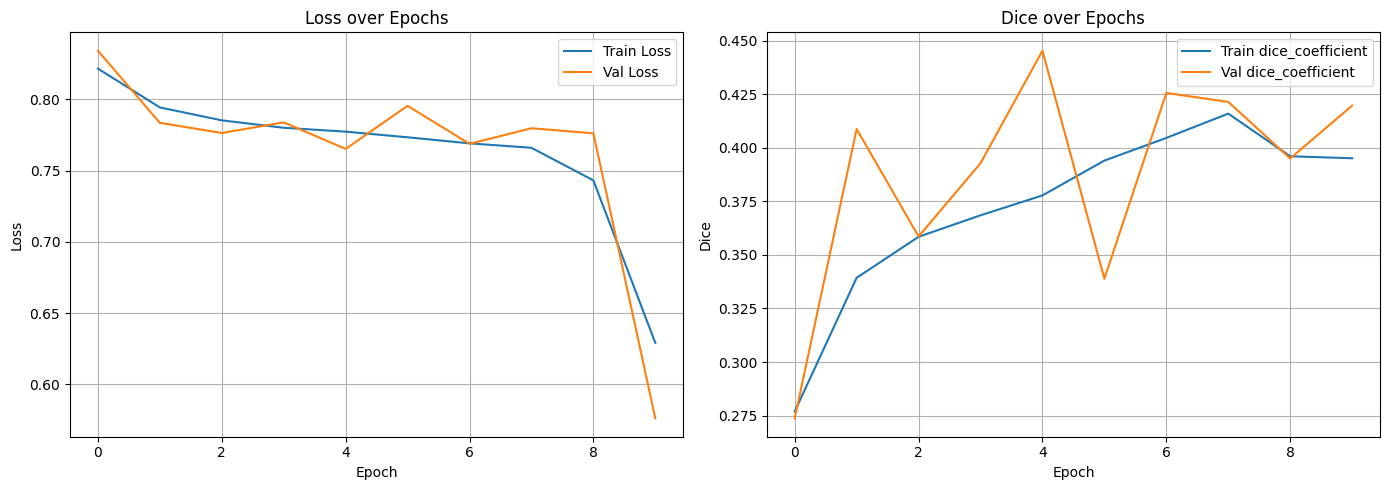

In [ ]:
plot_history(history)

In [ ]:
results = evaluate_segmentation(
    loader=test_loader,
    model=model,
    device=DEVICE,
    roi_size=roi_size
)

Evaluating: 100%|███████████████████████████████████████████████████| 24/24 [01:07<00:00,  2.81s/it]


In [ ]:
# ── ambil semua dice ──────────────────────────────────────────────
regions   = results["regions"]    # ET, TC, WT
per_class = results["per_class"]  # ET, NETC, SNFH, RC

# 6 unique metrics: ET(region), TC, WT, NETC, SNFH, RC
mean_all_dice = np.mean([
    regions["ET"]["dice"],
    regions["TC"]["dice"],
    regions["WT"]["dice"],
    per_class["NETC"]["dice"],
    per_class["SNFH"]["dice"],
    per_class["RC"]["dice"],
])

# ── print standard regions ────────────────────────────────────────
print("\nBRATS STANDARD EVALUATION")
print("-" * 60)
print(f"{'Region':<20}{'Dice':>12}{'Sens':>12}{'HD95':>12}")
print("-" * 60)

region_dice, region_sens, region_hd = [], [], []
for k, v in regions.items():
    region_dice.append(v["dice"])
    region_sens.append(v["sens"])
    if not np.isnan(v["hd95"]):
        region_hd.append(v["hd95"])
    print(f"{k:<20}{v['dice']:>12.4f}{v['sens']:>12.4f}{v['hd95']:>12.2f}")

print("-" * 60)
print(
    f"{'Mean':<20}"
    f"{safe_mean(region_dice):>12.4f}"
    f"{safe_mean(region_sens):>12.4f}"
    f"{safe_mean(region_hd):>12.2f}"
)
print("-" * 60)

# ── print per-class ───────────────────────────────────────────────
print("\nPER-CLASS EVALUATION")
print("-" * 60)
print(f"{'Class':<20}{'Dice':>12}{'Sens':>12}{'HD95':>12}")
print("-" * 60)

dice_all, sens_all, hd_all = [], [], []
for k, v in per_class.items():
    dice_all.append(v["dice"])
    sens_all.append(v["sens"])
    if not np.isnan(v["hd95"]):
        hd_all.append(v["hd95"])
    print(f"{k:<20}{v['dice']:>12.4f}{v['sens']:>12.4f}{v['hd95']:>12.2f}")

print("-" * 60)
print(
    f"{'Mean':<20}"
    f"{safe_mean(dice_all):>12.4f}"
    f"{safe_mean(sens_all):>12.4f}"
    f"{safe_mean(hd_all):>12.2f}"
)
print("-" * 60)

# ── FINAL: mean 6 unique metrics ──────────────────────────────────
print("\nFINAL TEST RESULT (6 Unique Metrics: ET+TC+WT+NETC+SNFH+RC)")
print("-" * 60)
print(f"Mean Dice : {mean_all_dice:.4f}")
print("-" * 60)


BRATS STANDARD EVALUATION
------------------------------------------------------------
Region                      Dice        Sens        HD95
------------------------------------------------------------
ET                        0.6070      0.6483        7.69
TC                        0.6564      0.9303       13.27
WT                        0.6851      0.9358       13.28
------------------------------------------------------------
Mean                      0.6495      0.8381       11.41
------------------------------------------------------------

PER-CLASS EVALUATION
------------------------------------------------------------
Class                       Dice        Sens        HD95
------------------------------------------------------------
ET                        0.6070      0.6483        7.69
NETC                      0.6498      0.9334       13.67
SNFH                      0.4105      0.5989       19.43
RC                        0.3359      0.5453       35.14
---------------

In [ ]:
# ── ambil semua dice ──────────────────────────────────────────────
regions   = results["regions"]    # ET, TC, WT
per_class = results["per_class"]  # ET, NETC, SNFH, RC

# ── hitung mean 6 unique metrics ─────────────────────────────────
mean_all_dice = np.mean([
    regions["ET"]["dice"],
    regions["TC"]["dice"],
    regions["WT"]["dice"],
    per_class["NETC"]["dice"],
    per_class["SNFH"]["dice"],
    per_class["RC"]["dice"],
])

mean_sens_6 = np.mean([
    regions["ET"]["sens"],
    regions["TC"]["sens"],
    regions["WT"]["sens"],
    per_class["NETC"]["sens"],
    per_class["SNFH"]["sens"],
    per_class["RC"]["sens"],
])

hd_values_6 = [
    regions["ET"]["hd95"],
    regions["TC"]["hd95"],
    regions["WT"]["hd95"],
    per_class["NETC"]["hd95"],
    per_class["SNFH"]["hd95"],
    per_class["RC"]["hd95"],
]
mean_hd_6 = safe_mean([h for h in hd_values_6 if not np.isnan(h)])

# ── print ─────────────────────────────────────────────────────────
print("\nFINAL TEST RESULT (6 Unique Metrics: ET+TC+WT+NETC+SNFH+RC)")
print("-" * 60)
print(f"{'Metric':<20}{'Dice':>12}{'Sens':>12}{'HD95':>12}")
print("-" * 60)
print(f"{'ET (region)':<20}{regions['ET']['dice']:>12.4f}{regions['ET']['sens']:>12.4f}{regions['ET']['hd95']:>12.2f}")
print(f"{'TC':<20}{regions['TC']['dice']:>12.4f}{regions['TC']['sens']:>12.4f}{regions['TC']['hd95']:>12.2f}")
print(f"{'WT':<20}{regions['WT']['dice']:>12.4f}{regions['WT']['sens']:>12.4f}{regions['WT']['hd95']:>12.2f}")
print(f"{'NETC':<20}{per_class['NETC']['dice']:>12.4f}{per_class['NETC']['sens']:>12.4f}{per_class['NETC']['hd95']:>12.2f}")
print(f"{'SNFH':<20}{per_class['SNFH']['dice']:>12.4f}{per_class['SNFH']['sens']:>12.4f}{per_class['SNFH']['hd95']:>12.2f}")
print(f"{'RC':<20}{per_class['RC']['dice']:>12.4f}{per_class['RC']['sens']:>12.4f}{per_class['RC']['hd95']:>12.2f}")
print("-" * 60)
print(f"{'Mean':<20}{mean_all_dice:>12.4f}{mean_sens_6:>12.4f}{mean_hd_6:>12.2f}")
print("-" * 60)


FINAL TEST RESULT (6 Unique Metrics: ET+TC+WT+NETC+SNFH+RC)
------------------------------------------------------------
Metric                      Dice        Sens        HD95
------------------------------------------------------------
ET (region)               0.6070      0.6483        7.69
TC                        0.6564      0.9303       13.27
WT                        0.6851      0.9358       13.28
NETC                      0.6498      0.9334       13.67
SNFH                      0.4105      0.5989       19.43
RC                        0.3359      0.5453       35.14
------------------------------------------------------------
Mean                      0.5574      0.7653       17.08
------------------------------------------------------------


In [ ]:
regions = results["regions"]

print("\nBRATS STANDARD EVALUATION")
print("-" * 60)

print(
    f"{'Region':<10}"
    f"{'Dice':>12}"
    f"{'Sens':>12}"
    f"{'HD95':>12}"
)

print("-" * 60)

dice_all = []
sens_all = []
hd_all   = []

for k, v in regions.items():

    dice_all.append(v["dice"])
    sens_all.append(v["sens"])

    if not np.isnan(v["hd95"]):
        hd_all.append(v["hd95"])

    print(
        f"{k:<10}"
        f"{v['dice']:>12.4f}"
        f"{v['sens']:>12.4f}"
        f"{v['hd95']:>12.2f}"
    )

print("-" * 60)

print(
    f"{'Mean':<10}"
    f"{safe_mean(dice_all):>12.4f}"
    f"{safe_mean(sens_all):>12.4f}"
    f"{safe_mean(hd_all):>12.2f}"
)

print("-" * 60)


BRATS STANDARD EVALUATION
------------------------------------------------------------
Region            Dice        Sens        HD95
------------------------------------------------------------
ET              0.6070      0.6483        7.69
TC              0.6564      0.9303       13.27
WT              0.6851      0.9358       13.28
------------------------------------------------------------
Mean            0.6495      0.8381       11.41
------------------------------------------------------------


In [ ]:
per_class = results["per_class"]

print("\nPER-CLASS EVALUATION")
print("-" * 70)

print(
    f"{'Class':<20}"
    f"{'Dice':>12}"
    f"{'Sens':>12}"
    f"{'HD95':>12}"
)

print("-" * 70)

dice_all = []
sens_all = []
hd_all   = []

for k, v in per_class.items():

    dice_all.append(v["dice"])
    sens_all.append(v["sens"])

    if not np.isnan(v["hd95"]):
        hd_all.append(v["hd95"])

    print(
        f"{k:<20}"
        f"{v['dice']:>12.4f}"
        f"{v['sens']:>12.4f}"
        f"{v['hd95']:>12.2f}"
    )

print("-" * 70)

print(
    f"{'Mean':<20}"
    f"{safe_mean(dice_all):>12.4f}"
    f"{safe_mean(sens_all):>12.4f}"
    f"{safe_mean(hd_all):>12.2f}"
)

print("-" * 70)


PER-CLASS EVALUATION
----------------------------------------------------------------------
Class                       Dice        Sens        HD95
----------------------------------------------------------------------
ET                        0.6070      0.6483        7.69
NETC                      0.6498      0.9334       13.67
SNFH                      0.4105      0.5989       19.43
RC                        0.3359      0.5453       35.14
----------------------------------------------------------------------
Mean                      0.5008      0.6815       18.98
----------------------------------------------------------------------


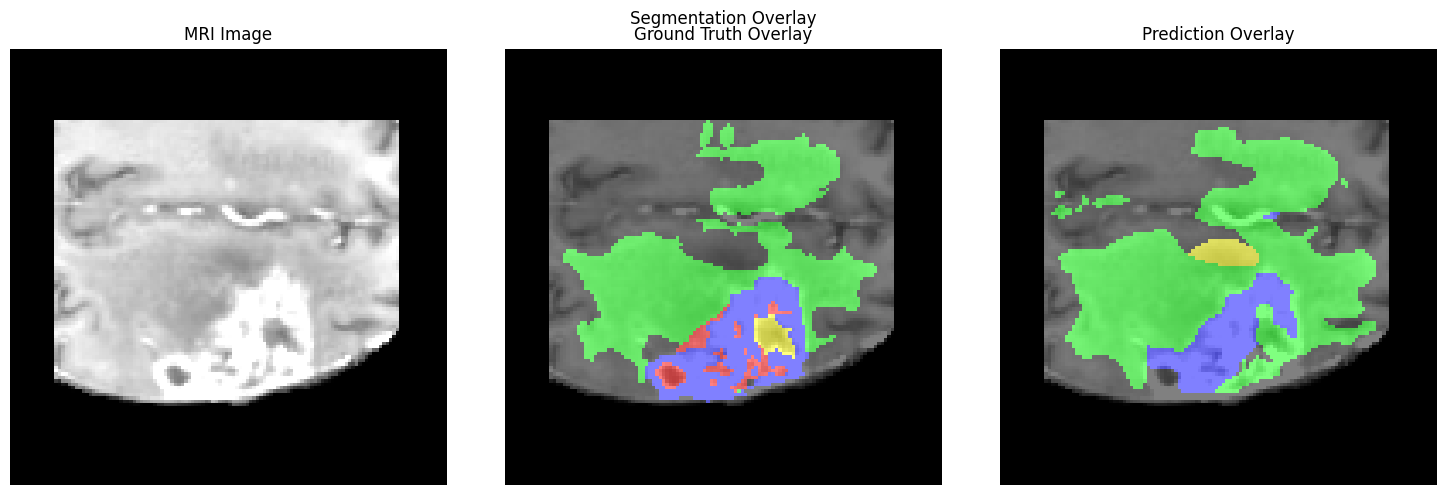

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from monai.inferers import sliding_window_inference


def visualize_segmentation_overlay(image, label, pred, slice_idx=None, title="Segmentation Overlay"):
    if torch.is_tensor(image): image = image.detach().cpu().numpy()
    if torch.is_tensor(label): label = label.detach().cpu().numpy()
    if torch.is_tensor(pred):  pred  = pred.detach().cpu().numpy()

    if image.ndim == 4: image = image[0]
    if label.ndim == 4: label = label[0]
    if pred.ndim  == 4: pred  = pred[0]

    if slice_idx is None:
        slice_idx = image.shape[2] // 2

    img_slice = image[:, :, slice_idx]
    gt_slice  = label[:, :, slice_idx]
    pr_slice  = pred[:, :, slice_idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_slice, cmap="gray")
    axes[0].set_title("MRI Image")
    axes[0].axis("off")

    axes[1].imshow(img_slice, cmap="gray")
    overlay_gt = np.zeros((*gt_slice.shape, 3))
    overlay_gt[gt_slice == 1] = [1, 0, 0]
    overlay_gt[gt_slice == 2] = [0, 1, 0]
    overlay_gt[gt_slice == 3] = [0, 0, 1]
    overlay_gt[gt_slice == 4] = [1, 1, 0]
    axes[1].imshow(overlay_gt, alpha=0.5)
    axes[1].set_title("Ground Truth Overlay")
    axes[1].axis("off")

    axes[2].imshow(img_slice, cmap="gray")
    overlay_pr = np.zeros((*pr_slice.shape, 3))
    overlay_pr[pr_slice == 1] = [1, 0, 0]
    overlay_pr[pr_slice == 2] = [0, 1, 0]
    overlay_pr[pr_slice == 3] = [0, 0, 1]
    overlay_pr[pr_slice == 4] = [1, 1, 0]
    axes[2].imshow(overlay_pr, alpha=0.5)
    axes[2].set_title("Prediction Overlay")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


model.eval()

with torch.no_grad():
    for batch in test_loader:

        image_t1 = batch["image_t1"].to(device)
        image_t2 = batch["image_t2"].to(device)
        label    = batch["label"].to(device)

        if image_t1.ndim == 4: image_t1 = image_t1.unsqueeze(0)
        if image_t2.ndim == 4: image_t2 = image_t2.unsqueeze(0)
        if label.ndim == 4:    label    = label.unsqueeze(0)

        t1c = image_t1[:, 0:1]
        t1n = image_t1[:, 1:2]
        t2f = image_t2[:, 0:1]
        t2w = image_t2[:, 1:2]

        pred = model_inferer(t1c, t1n, t2f, t2w)

        if pred.shape[2:] != label.shape[2:]:
            pred = F.interpolate(pred, size=label.shape[2:], mode="trilinear", align_corners=False)

        pred = torch.argmax(pred, dim=1)

        visualize_segmentation_overlay(
            image=image_t1[0, 0],
            label=label[0],
            pred=pred[0]
        )

        break

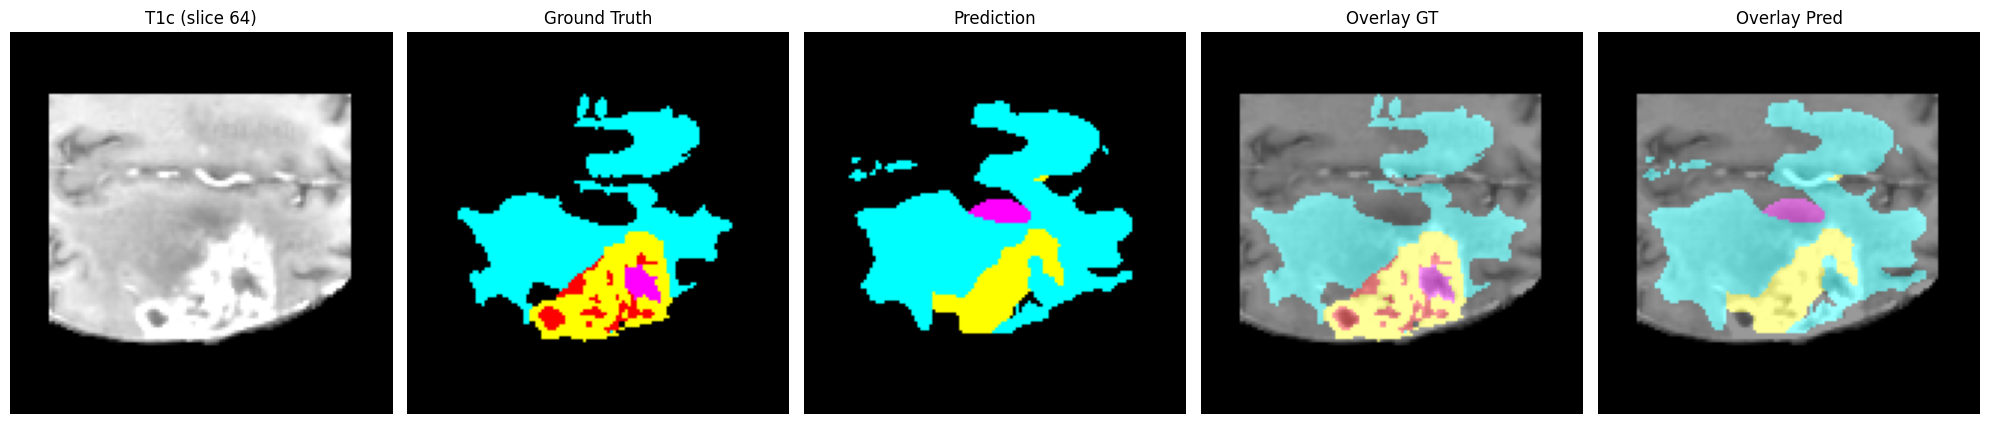

Unique GT  : [0 1 2 3 4]
Unique Pred: [0 2 3 4]
Class: 0=BG, 1=ET, 2=NETC, 3=SNFH, 4=RC


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

model.eval()

batch  = next(iter(test_loader))
sample = batch[0] if isinstance(batch, list) else batch

x1 = sample["image_t1"].to(device)
x2 = sample["image_t2"].to(device)
y  = sample["label"].to(device)

if x1.ndim == 4: x1 = x1.unsqueeze(0)
if x2.ndim == 4: x2 = x2.unsqueeze(0)
if y.ndim == 4:  y  = y.unsqueeze(0)
if y.shape[1] == 1: y = y[:, 0]

t1c = x1[:, 0:1]
t1n = x1[:, 1:2]
t2f = x2[:, 0:1]
t2w = x2[:, 1:2]

with torch.no_grad():
    pred = model_inferer(t1c, t1n, t2f, t2w)

if pred.shape[2:] != y.shape[1:]:
    pred = torch.nn.functional.interpolate(
        pred, size=y.shape[1:], mode="trilinear", align_corners=False
    )

pred_cls = torch.argmax(pred, dim=1)[0].cpu().numpy().astype(np.uint8)
label_np = y[0].cpu().numpy().astype(np.uint8)
t1c_img  = t1c[0, 0].cpu().numpy()

D         = pred_cls.shape[-1]
slice_idx = D // 2

t1c_slice  = t1c_img[:, :, slice_idx]
gt_slice   = label_np[:, :, slice_idx]
pred_slice = pred_cls[:, :, slice_idx]

class_names = ["BG", "ET", "NETC", "SNFH", "RC"]
cmap        = ListedColormap(["black", "red", "cyan", "yellow", "magenta"])
bounds      = np.arange(-0.5, 5.5, 1.0)
norm        = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(20, 6))

plt.subplot(1, 5, 1)
plt.imshow(t1c_slice, cmap="gray")
plt.title(f"T1c (slice {slice_idx})")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(gt_slice, cmap=cmap, norm=norm)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(pred_slice, cmap=cmap, norm=norm)
plt.title("Prediction")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(t1c_slice, cmap="gray")
plt.imshow(gt_slice, cmap=cmap, norm=norm, alpha=0.4)
plt.title("Overlay GT")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(t1c_slice, cmap="gray")
plt.imshow(pred_slice, cmap=cmap, norm=norm, alpha=0.4)
plt.title("Overlay Pred")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Unique GT  :", np.unique(gt_slice))
print("Unique Pred:", np.unique(pred_slice))
print("Class:", ", ".join([f"{i}={n}" for i, n in enumerate(class_names)]))